In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
import lmfit
import ray
import os
import timeit

from suncalc import get_position, get_times
from datetime import datetime

from bio_optics.water import absorption, attenuation, backscattering, scattering, lee
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.models import hereon, model
from bio_optics.helper import resampling, utils, owt, indices, plotting
from bio_optics.water import fluorescence

In [2]:
%reload_ext autoreload

In [3]:
## check, that the correct version is loaded:
import bio_optics
bio_optics.water.__file__

'C:\\Users\\Dagmar\\PycharmProjects\\bio_optics\\bio_optics\\water\\__init__.py'

# MOMO reflectances  
With and without glint.

In [5]:
## Simulated spectra MOMO Rrs
# momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\" + position+"\\"
locName = "oder-frankfurt" # "vortsjarv" #"oder-frankfurt" # 'finnmaid-helsinki'
partFname = "AQUATIME_D2.1.0_RD-" + locName

def read_spectra(path, fname):
    Rrs = pd.read_csv(path + fname, header=0)
    Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
    owtDF = Rrs[varList].copy()
    Rrs = Rrs.drop(columns=varList)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    wlstr = [str(a) for a in wl]
    return Rrs, wl, wlstr, owtDF

momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\oder_frankfurt\\"
# momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\"+locName+"\\"

fname = os.listdir(momopath)
fname = [fn for fn in fname if 'Rrs_v0.3' in fn]
Rrs_glint, wl, wlstr, owtDF_glint = read_spectra(momopath, fname[0])

fname = os.listdir(momopath)
fname = [fn for fn in fname if 'RrsNoGlint_v0.3' in fn]
Rrs_noglint, wl, wlstr, owtDF_noglint = read_spectra(momopath, fname[0])


['2019-08-16T12:00:00.000000000' '2022-10-03T12:00:00.000000000'
 '2024-05-31T12:00:00.000000000' '2021-03-21T12:00:00.000000000'
 '2018-08-02T12:00:00.000000000' '2020-10-28T12:00:00.000000000'
 '2023-06-17T12:00:00.000000000' '2015-10-10T12:00:00.000000000']


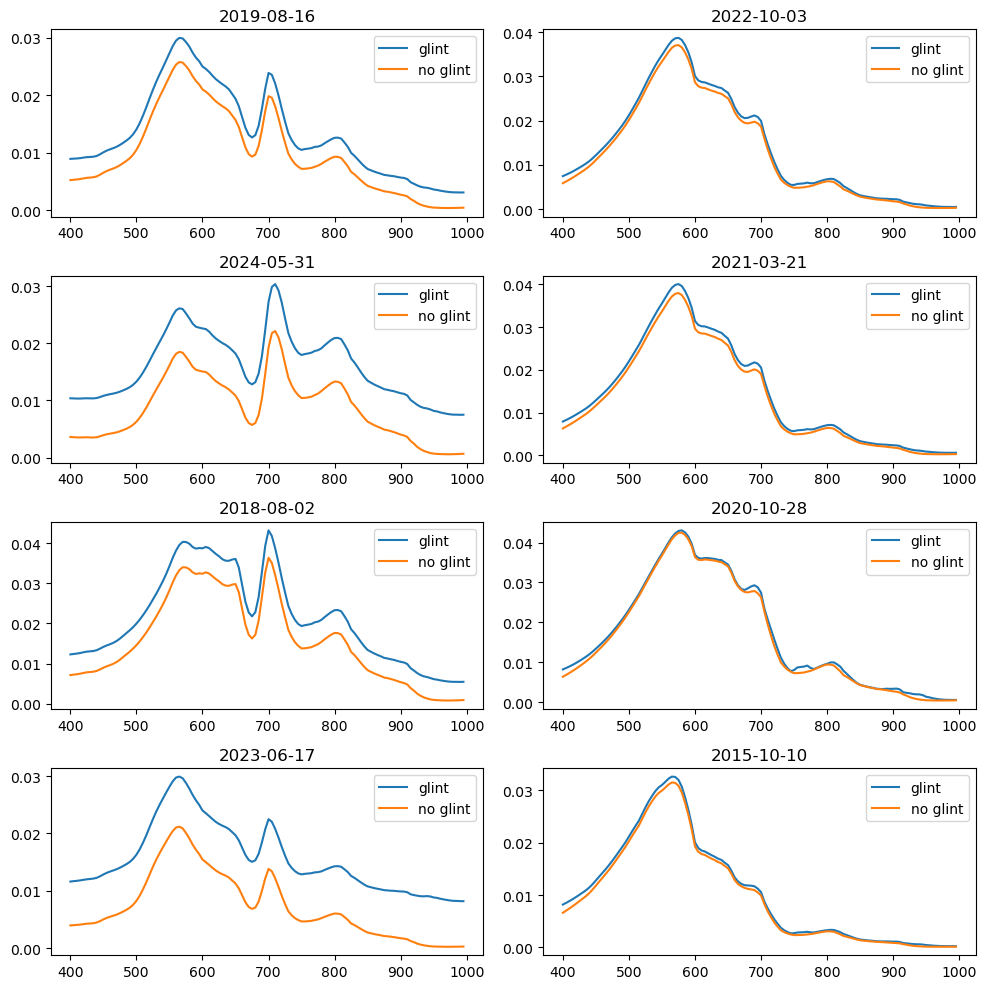

In [6]:
Nx, Ny = (2, 4)
ind = np.random.choice(Rrs_glint.index, Nx*Ny, replace=False)
print(ind)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,10))
for ix in range(Nx):
    for iy in range(Ny):
        ax[iy, ix].plot(wl, Rrs_glint.loc[ind[iy*Nx + ix]].values, '-', label='glint')
        ax[iy, ix].plot(wl, Rrs_noglint.loc[ind[iy*Nx + ix]].values, '-', label='no glint')
        ax[iy, ix].legend()
        ax[iy, ix].set_title(str(ind[iy*Nx + ix]).split('T')[0])

fig.tight_layout()
plt.show()

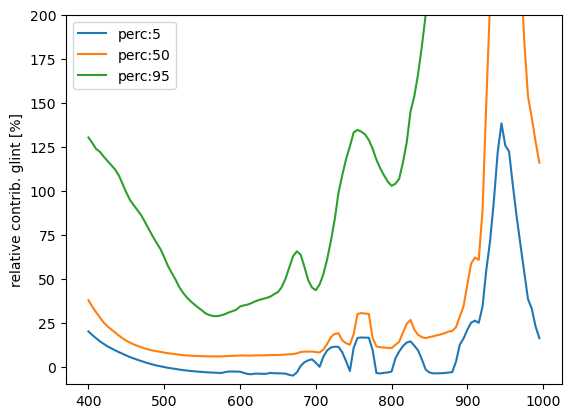

In [82]:
glintTest = (Rrs_glint - Rrs_noglint)/Rrs_noglint
perc = [5, 50, 95]
glintPerc = np.percentile(glintTest, perc, axis=0)
for i, x in enumerate(glintPerc):
    plt.plot(wl, x*100, '-', label='perc:'+str(perc[i]))
plt.legend()
plt.ylim((-10, 200))
plt.ylabel('relative contrib. glint [%]')
plt.show()

# Forward Bi-Model  
- Use insitu data and replace values from inversion (the results ...allOWTS... are organised in the original order)
- model Spectra with Bi bio-optical model

## Setup Parameter Functions and global variables

In [2]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.0058, vary=False)  # Diatoms
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green
    params.add('b_ratio_C_2', value=0.0042, vary=False)  # cryptophyte
    params.add('b_ratio_C_3', value=0.0082, vary=False)  # cyano blue
    params.add('b_ratio_C_4', value=0.001, vary=False)  # cyano red
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    else:
        params.add('b_ratio_C_5', value=0.0129, vary=False)  # coccolithophores , Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.0109, vary=False)  # case-1 , Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    # params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=True)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.0185, min=0.005, max=0.032, vary=True) # test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=True, vary=False)
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params

In [3]:
# Define wavelength range and sampling rate
wavelengths=np.arange(400,900, 5)

# Select iop-model setup!
AlgaeGroupType = 'HEREON' #'Standard' # 'Standardv2': HEREON, 'Standardv3': 'Standard', NSSummerBloomsv3': 'Summer'


# global inputs that don't change with fit params
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'HEREON':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
if AlgaeGroupType == 'Standard':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
if AlgaeGroupType == 'Summer':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
b_bw_res = backscattering.b_bw(wavelengths=wavelengths, fresh=False)

da_W_div_dT_res = resampling.resample_da_W_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E_0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.E_dd(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.E_dsa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.E_dsr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

## Read full inversion IOP file

In [4]:
outpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
# path = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\Helsinki\\input_simulations\\"
path = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\"
location = 'Helsinki'

fnames = os.listdir(path)
iopFnames = [fn for fn in fnames if fn.startswith('inverted_IOP') and fn.endswith('allOWTs.txt') and location in fn]
print(iopFnames)

# paramDF = pd.read_csv(path + iopFnames[0], header=0, sep='\t')
paramDF = pd.read_csv(path + iopFnames[0], header=0)
if 'date' in paramDF.columns.values:
    paramDF = paramDF.drop('date', axis=1)
# print(paramDF.iloc[0,:])
# print(paramDF.columns.values)
paramList = ['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7', 'C_Y', 'C_ism', 'L_fl_lambda0', 'L_fl_phycocyanin',
             'L_fl_phycoerythrin', 'b_ratio_C_0', 'b_ratio_C_1', 'b_ratio_C_2', 'b_ratio_C_3', 'b_ratio_C_4',
             'b_ratio_C_5', 'b_ratio_C_6', 'b_ratio_C_7', 'b_ratio_md', 'b_ratio_bd', 'A_md', 'A_bd', 'S_md', 'S_bd',
             'S_cdom', 'C_md', 'C_bd', 'K', 'lambda_0_cdom', 'lambda_0_md', 'lambda_0_bd', 'lambda_0_c_d', 'lambda_0_phy',
             'gamma_d', 'x0', 'x1', 'x2', 'A', 'E0', 'E1', 'W', 'fwhm1', 'fwhm2', 'fwhm_phycocyanin', 'fwhm_phycoerythrin',
             'lambda_C1', 'lambda_C2', 'lambda_C_phycocyanin', 'lambda_C_phycoerythrin', 'double', 'interpolate',
             'Gw0', 'Gw1', 'Gp0', 'Gp1', 'error_method', 'theta_sun', 'theta_view', 'n1', 'n2', 'kappa_0', 'fresh',
             'T_W', 'T_W_0', 'offset', 'fit_surface']
# for v in paramDF.columns.values:
#     if len(np.unique(paramDF[v])) > 1 and v != 'C_phy':
#         paramList.append(v)
paramDF.drop(columns = ['C_phy'], inplace=True)

['inverted_IOP_bio_optics_HEREONfull_CHIME_sim_HEATWISE_Helsinki_SiljaSerenade_allOWTs.txt']


In [6]:
paramDF

,Unnamed: 0,C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7,C_Y,...,alpha,beta,g_dd,g_dsr,g_dsa,d_r,f_dd,f_ds,offset,fit_surface
0,0,8.009653e-02,0.0,0.0,0.019903,0.0,0.0,0.0,0.0,0.474351,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
1,1,7.889359e-02,0.0,0.0,0.021106,0.0,0.0,0.0,0.0,0.494600,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
2,2,9.681224e-02,0.0,0.0,0.003188,0.0,0.0,0.0,0.0,0.445048,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
3,3,8.901558e-02,0.0,0.0,0.010984,0.0,0.0,0.0,0.0,0.446575,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
4,4,8.913490e-02,0.0,0.0,0.010865,0.0,0.0,0.0,0.0,0.425791,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,287,1.944951e-01,0.0,0.0,0.705969,0.0,0.0,0.0,0.0,0.529969,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
288,288,1.940299e-36,0.0,0.0,1.000299,0.0,0.0,0.0,0.0,0.491312,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
289,289,7.785141e-02,0.0,0.0,0.022149,0.0,0.0,0.0,0.0,0.536810,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0
290,290,4.746554e-47,0.0,0.0,1.028825,0.0,0.0,0.0,0.0,0.534592,...,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0


## Read insitu data and exchange values

In [5]:
## Exchange columns with input and order them like inversion results by OWT!
# OWTList = [ '1', '2', '3a_g', '3a_y', '3b', '4a_g', '4a_y', '4b', '5a', '5b', '6', '7']
regionName = 'Helsinki_SS'

metaDict = {
    'elbe_bunthaus' : {'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_bunthaus\\",
                    'datasetName' : 'CHIME_sim_AQUATIME_elbe_bunthaus'},
    'dalaro-2': {'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\dalaro-2\\",
             'datasetName': 'CHIME_sim_AQUATIME_dalaro-2'},
    'pyhajarvi': {'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\pyhajarvi\\",
                  'datasetName' :'CHIME_sim_AQUATIME_pyhajarvi'},
    'elbe_seemannshöft' :{ 'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_seemannshöft\\",
                           'datasetName': 'CHIME_sim_AQUATIME_elbe-seemannshöft' },
    'oder_frankfurt': {'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_frankfurt\\",
                       'datasetName': 'CHIME_sim_AQUATIME_oder_frankfurt'},
    'oder_hohenwutzen': {'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_hohenwutzen\\",
                         'datasetName': 'CHIME_sim_AQUATIME_oder_hohenwutzen'},
    'Helsinki_SS': {
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\", 
        'datasetName': '',
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Helsinki\input_simulations\\",
        'datasetNameIOP': 'helsinki_silja_serenade'},
    'Helsinki_FM': {
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"},
    'Mueggelsee': {'path' : "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"}
}

# path = metaDict[regionName]['path']

iop_path = metaDict[regionName]['iop_path']
datasetNameIOP = metaDict[regionName]['datasetNameIOP']

fname = os.listdir(iop_path)
fname = [fn for fn in fname if 'IOP' in fn and fn.startswith(datasetNameIOP) and 'v0.1b' in fn]
print(fname)
iop_insitu = pd.read_csv(iop_path+ fname[0], sep=',')

['helsinki_silja_serenade_IOP_v0.1b.csv']


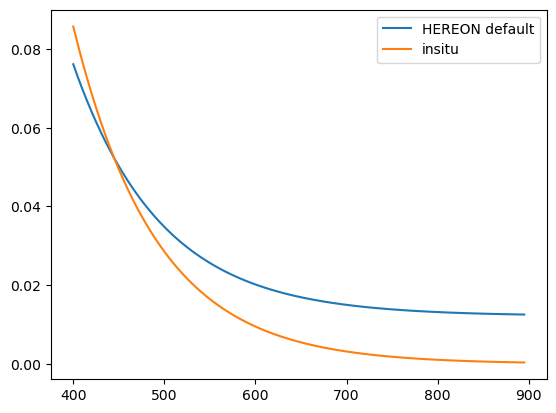

In [11]:
### check aNAP and a_md from HEREON
## adjust a_md_spec_res with insitu values 'anap_spec(440) [m2 g-1]'

plt.plot(wavelengths, a_md_spec_res, '-', label='HEREON default')
anap_spec440 = np.unique(np.round(iop_insitu['anap_spec(440) [m2 g-1]'].values, 5))
S_xd = np.unique(np.round(iop_insitu['Snap [1/nm]'].values, 5))
if len(anap_spec440)==1:
    plt.plot(wavelengths, anap_spec440*np.exp(-S_xd *(wavelengths-440)), '-', label='insitu')
plt.legend()
plt.show()

In [7]:
anap_spec440

array([0.0552, 0.0552])

In [10]:
## for replacement:
IOPDict = {
    'C_0': 'Ckie [µg/l]', 
    'C_1': None, 
    'C_2': None, #'Ccry [µg/l]'
    'C_3': 'Cbl [µg/l]',
    'C_4': None, 
    'C_5': None, 
    'C_6': None, 
    'C_Y': 'ag(440) [1/m]', 
    'C_ism': 'NAP [mg/l]', 
    'S_md': 'Snap [1/nm]', 
    'S_cdom' : 'Sg [1/nm]' 
}

for key in IOPDict.keys():
    if IOPDict[key] is None:
        paramDF[key] = 0.
    else:
        y = iop_insitu[IOPDict[key]].values
        print(key, y[:10])
        ID = np.isnan(y)
        if np.sum(ID)>0:
            y[ID] =  0.
        paramDF[key] = y

C_0 [ 2.18066568  2.2390477   2.30585599  2.46956639  2.26462745  2.5562366
  4.30248087  3.39752616  3.77443458 16.86163655]
C_3 [nan nan nan nan nan nan nan nan nan  0.]
C_Y [0.18806794 0.21960659 0.25479349 0.17620504 0.20148655 0.2197692
 0.23084623 0.26362199 0.22461713 0.34047606]
C_ism [5.15614581 5.16168461 4.55650864 4.36466726 4.63792096 5.38923295
 5.55998239 5.04223761 5.20335594 3.42606311]
S_md [0.011 0.011 0.011 0.011 0.011 0.011 0.011 0.011 0.011 0.011]
S_cdom [0.02147749 0.02132791 0.02116282 0.02153411 0.02141358 0.02132685
 0.02127453 0.02112161 0.02130399 0.02076658]


In [11]:
@ray.remote
def simulate_chunk(
                   paramDF_chunk,  # iops and variables from Inversion
                   wavelengths,
                   a_md_spec_res,
                   a_bd_spec_res,
                   a_w_res,
                   a_i_spec_res,
                   b_bw_res,
                   b_i_spec_res,
                   h_C_res,
                   h_C_phycocyanin_res,
                   h_C_phycoerythrin_res,
                   da_W_div_dT_res,
                   E_0_res,
                   a_oz_res,
                   a_ox_res,
                   a_wv_res,
                   E_dd_res,
                   E_dsa_res,
                   E_dsr_res,
                   E_d_res,
                   n2_res):

    params = set_default_parameters(AlgaeGroupType)

    for i in np.arange(paramDF_chunk.shape[0]):
        for p in paramList:
            # Change parameters object accordingly.
            params.add(p, value=paramDF_chunk[p].values[i])

        if i == 0:
            print(params)
            R_rs_sim = hereon.forward(parameters=params,
                                      wavelengths=wavelengths,
                                      a_md_spec_res=a_md_spec_res,
                                      a_bd_spec_res=a_bd_spec_res,
                                      a_w_res=a_w_res,
                                      a_i_spec_res=a_i_spec_res,
                                      b_bw_res=b_bw_res,
                                      b_i_spec_res=b_i_spec_res,
                                      h_C_res=h_C_res,
                                      h_C_phycocyanin_res=h_C_phycocyanin_res,
                                      h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                                      da_W_div_dT_res=da_W_div_dT_res,
                                      E_0_res=E_0_res,
                                      a_oz_res=a_oz_res,
                                      a_ox_res=a_ox_res,
                                      a_wv_res=a_wv_res,
                                      E_dd_res=E_dd_res,
                                      E_dsa_res=E_dsa_res,
                                      E_dsr_res=E_dsr_res,
                                      E_d_res=E_d_res,
                                      n2_res=n2_res,
                                      Ls_Ed=[])
        else:
            R_rs_sim = np.vstack((R_rs_sim, hereon.forward(parameters=params,
                                                           wavelengths=wavelengths,
                                                           a_md_spec_res=a_md_spec_res,
                                                           a_bd_spec_res=a_bd_spec_res,
                                                           a_w_res=a_w_res,
                                                           a_i_spec_res=a_i_spec_res,
                                                           b_bw_res=b_bw_res,
                                                           b_i_spec_res=b_i_spec_res,
                                                           h_C_res=h_C_res,
                                                           h_C_phycocyanin_res=h_C_phycocyanin_res,
                                                           h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                                                           da_W_div_dT_res=da_W_div_dT_res,
                                                           E_0_res=E_0_res,
                                                           a_oz_res=a_oz_res,
                                                           a_ox_res=a_ox_res,
                                                           a_wv_res=a_wv_res,
                                                           E_dd_res=E_dd_res,
                                                           E_dsa_res=E_dsa_res,
                                                           E_dsr_res=E_dsr_res,
                                                           E_d_res=E_d_res,
                                                           n2_res=n2_res,
                                                           Ls_Ed=[])
                                  ))

    # print(R_rs_sim.shape)
    return R_rs_sim


In [14]:
if paramDF.shape[0] < 300:
    num_chunks = 1
elif paramDF.shape[0] < 1000:
    num_chunks = 3
else:
    num_chunks = 9  # Number of chunks to split the DF into

chunk_size = paramDF.shape[0] // num_chunks  # Size of each chunk
chunks = [paramDF.iloc[i:i + chunk_size, :] for i in range(0, paramDF.shape[0], chunk_size)]  # Split the DF into chunks
while chunks[-1].shape[0] == 1:
    num_chunks -= 1
    chunk_size = paramDF.shape[0] // num_chunks  # Size of each chunk
    chunks = [paramDF.iloc[i:i + chunk_size, :] for i in range(0, paramDF.shape[0], chunk_size)]  # Split the DF into chunks


print(chunks[-1].shape[0])
print('chunks N', len(chunks))
ray.shutdown()

start = timeit.default_timer()

# Parallelize the processing of the chunks using ray
chunk_refs = [ray.put(chunk) for chunk in chunks]  # Put the chunks into the object store
result_refs = [simulate_chunk.remote(chunk_ref,
                                   # params=params,
                                   wavelengths=wavelengths,
                                   a_md_spec_res=a_md_spec_res,
                                   a_bd_spec_res=a_bd_spec_res,
                                   a_w_res=a_w_res,
                                   a_i_spec_res=a_i_spec_res,
                                   b_bw_res=b_bw_res,
                                   b_i_spec_res=b_i_spec_res,
                                   h_C_res=h_C_res,
                                   h_C_phycocyanin_res=h_C_phycocyanin_res,
                                   h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                                   da_W_div_dT_res=da_W_div_dT_res,
                                   E_0_res=E_0_res,
                                   a_oz_res=a_oz_res,
                                   a_ox_res=a_ox_res,
                                   a_wv_res=a_wv_res,
                                   E_dd_res=E_dd_res,
                                   E_dsa_res=E_dsa_res,
                                   E_dsr_res=E_dsr_res,
                                   E_d_res=E_d_res,
                                   n2_res=n2_res) for chunk_ref in chunk_refs]  # Process the chunks in parallel

results = ray.get(result_refs)

# Concatenate the results from the processed chunks
processed_data = np.concatenate(results)

stop = timeit.default_timer()
print('Time: ', stop - start)


R_rs_sim = pd.DataFrame(processed_data, columns=wavelengths.astype(str))
# R_rs_sim.to_csv(outpath + "bio-optics_Rrs_" + AlgaeGroupType + "_simulation_" + iopFnames[0], header=True, sep='\t', index=False)

292
chunks N 1


2026-02-18 16:16:30,597	INFO worker.py:1664 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


(simulate_chunk pid=15760) Parameters([('C_0', <Parameter 'C_0', value=2.180665682352941, bounds=[-inf:inf]>), ('C_1', <Parameter 'C_1', value=0.0, bounds=[-inf:inf]>), ('C_2', <Parameter 'C_2', value=0.0, bounds=[-inf:inf]>), ('C_3', <Parameter 'C_3', value=0.0, bounds=[-inf:inf]>), ('C_4', <Parameter 'C_4', value=0.0, bounds=[-inf:inf]>), ('C_5', <Parameter 'C_5', value=0.0, bounds=[-inf:inf]>), ('C_6', <Parameter 'C_6', value=0.0, bounds=[-inf:inf]>), ('C_7', <Parameter 'C_7', value=0.0, bounds=[-inf:inf]>), ('C_Y', <Parameter 'C_Y', value=0.1880679370446244, bounds=[-inf:inf]>), ('C_ism', <Parameter 'C_ism', value=5.156145813653618, bounds=[-inf:inf]>), ('L_fl_lambda0', <Parameter 'L_fl_lambda0', value=0.0416850426853174, bounds=[-inf:inf]>), ('L_fl_phycocyanin', <Parameter 'L_fl_phycocyanin', value=0.199933967071123, bounds=[-inf:inf]>), ('L_fl_phycoerythrin', <Parameter 'L_fl_phycoerythrin', value=0.0, bounds=[-inf:inf]>), ('b_ratio_C_0', <Parameter 'b_ratio_C_0', value=0.0058, b

RayTaskError(TypeError): [36mray::simulate_chunk()[39m (pid=15760, ip=127.0.0.1)
  File "python\ray\_raylet.pyx", line 1675, in ray._raylet.execute_task
  File "C:\Users\Dagmar\AppData\Local\Temp\ipykernel_10868\1889065741.py", line 34, in simulate_chunk
  File "F:\Anaconda_envs\py310_keras3\lib\site-packages\bio_optics\models\hereon.py", line 225, in forward
    a_res = absorption.a_total(wavelengths=wavelengths,
  File "F:\Anaconda_envs\py310_keras3\lib\site-packages\bio_optics\water\absorption.py", line 880, in a_total
    a_wc = correct_a_phy(a_phy_res=a_phy_res, wavelengths=wavelengths, C_phy=C_phy, A=A, E0=E0, E1=E1, lambda_0_phy=lambda_0_phy, interpolate=interpolate) + \
  File "F:\Anaconda_envs\py310_keras3\lib\site-packages\bio_optics\water\absorption.py", line 815, in correct_a_phy
    if interpolate:
TypeError: __bool__ should return bool, returned numpy.bool_

# Consistency check implementations  
Reference is the web-based HEREON model implementation.  
Test systematically, that our IOPs are correctly implemented.  
**Example data 1: HEATWISE Helsinki Silja Serenade, spectrum 0. Only Diatoms**  
**Example data 2: HEATWISE Helsinki Silja Serenade, spectrum 234. with Diatoms + Cyano, minimum NAP**

## Read all data

In [7]:
# general list of inversion versions available
# Determines: inversion dict and forward dict 
# Inv0.5: C0, C1, C3, Cism, CY. changed b_phy to implementation in HEREON web model! lower b_phy should lead to higher NAP (which was amiss)
# Inv0.5b: C0, C1, C2, C3, Cism, CY + offset! changed b_phy to implementation in HEREON web model! lower b_phy should lead to higher NAP (which was amiss)
# Inv0.5c: C0, C1, C2, C3, Cism, CY. fit: 400-750nm (and before). changed b_phy to implementation in HEREON web model! lower b_phy should lead to higher NAP (which was amiss)
# Inv0.5d: C0, C1, C2, C3, Cism, CY. extend 400-900 for fit. changed b_phy to implementation in HEREON web model! lower b_phy should lead to higher NAP (which was amiss)
versionInvList = ['Inv0.5', 'Inv0.5c', 'Inv0.5d']
colorList = ['aqua', 'lightblue', 'grey']
# versionInvList = ['Inv0.2b', 'Inv0.2c', 'Inv0.2d', 'Inv0.2e'] # helsinki_ss: ['Inv0.1', 'Inv0.2', 'Inv0.2b', 'Inv0.2c', 'Inv0.2d' ] # Inv0.1, Inv0.2, Inv0.2b
# colorList = ['aqua', 'goldenrod', 'brown', 'grey']

### Read MOMO data

In [8]:
## Simulated spectra MOMO Rrs
# momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\" + position+"\\"
locName = "oder-frankfurt" # 'finnmaid-helsinki' silja-helsinki
partFname = "HEATWISE_D2.1.0_RD-" + locName

if locName == "silja-helsinki":
    momopath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
if locName == 'finnmaid-helsinki':
    momopath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
if locName == 'oder-frankfurt':
    momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_frankfurt\\"

fname = os.listdir(momopath)
# fname = [fn for fn in fname if 'Rrs' in fn]
fname = [fn for fn in fname if 'RrsNoGlint_v0.3' in fn]
print(fname)
Rrs = pd.read_csv(momopath + fname[0], header=0)
Rrs['date'] = pd.to_datetime(Rrs['date'])
Rrs = Rrs.set_index('date')
# wl = np.arange(400, 1000, 5)
# wlStr = [str(a) for a in wl]
# wl = np.asarray([float(a) for a in Rrs.columns.values])

varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
owtDF = Rrs[varList].copy()
Rrs = Rrs.drop(columns=varList)
wl = np.asarray([float(a) for a in Rrs.columns.values])
wlStr = [str(a) for a in wl]

['AQUATIME_D2.1.0_RD-oder-frankfurt_irregular-chime-simulated-5nm-RrsNoGlint_v0.3.csv']


### Read Inversion data (all versions)  

In [7]:
## Inversion data (IOPs and Simulations)
# path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\"
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\"

positionList = ['helsinki_ss', 'helsinki_fm', 'berlin_mueggelsee']
# timezoneList = ['Etc/GMT', 'Etc/GMT', 'Etc/GMT']
# positionList = ['oder_frankfurt']

position = positionList[2]
timezone = 'Etc/GMT'

simDict = {}
invDict = {}
wlinvDict = {}

# for versionInv in versionInvList:
#     invFname = os.listdir(path)
#     invFname = [fn for fn in invFname if position in fn and 'allOWTs_'+versionInv+'.txt' in fn]  
#     print(invFname)
    
#     inv = pd.read_csv(path + invFname[0])
#     inv['date'] = pd.to_datetime(inv['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
#     inv = inv.set_index('date')
#     invDict[versionInv] = inv
    
#     sim = pd.read_csv(path + invFname[1])
#     sim['date'] = pd.to_datetime(sim['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
#     sim = sim.set_index('date')
#     simDict[versionInv] = sim

#     wlinv = np.asarray([float(a) for a in sim.columns.values[1:]])
#     wlinvDict[versionInv] = wlinv

### Read insitu IOP data  

In [9]:
## IOP Input to simulations
inputPath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\"
metaDict = {'helsinki_ss': {'folder': 'Helsinki\\input_simulations' , 'fileName':  'helsinki_silja_serenade_IOP_v0.1b.csv'}, # helsinki_silja_serenade_daily_v0.3.cvs
         'helsinki_fm': {'folder': 'Helsinki\\input_simulations', 'fileName': 'helsinki_finnmaid_daily_v0.3.csv'}, 
        'berlin_mueggelsee': {'folder': 'Muggelsee - Berlin\\input_simulations' , 'fileName': 'berlin_muggelsee_IOP_v0.3.csv'}, 
       }

# inputPath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\\"
# metaDict = {'oder_frankfurt': {'folder': 'Case Study 3 Oder_Frankfurt', 'fileName': 'oder-river_frankfurt_v0.3.csv'}}

folder = metaDict[position]['folder']
fname = metaDict[position]['fileName']

insitu = pd.read_csv(inputPath + folder + '\\'+ fname)
timeList = ['date', 'datetime', 'valid_time', 'DATE']
timeVarname = [a for a in timeList if a in insitu.columns.values]
print(timeVarname)
timeTest = np.asarray([str(t).split(' ')[0] for t in insitu[timeVarname[0]].values])
insitu['date'] = pd.to_datetime(timeTest) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
insitu = insitu.set_index('date')
insitu.columns.values

['datetime']


array(['datetime', 'Temp °C', 'Salinity [PSU]', 'Chlg [µg/l]',
       'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]',
       'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'ag(440) [1/m]',
       'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]',
       'anap_spec(440) [m2 g-1]', 'Snap [1/nm]', 'latitude_station',
       'longitude_station', 'latitude_cams', 'longitude_cams', 'u10',
       'v10', 'bcaod550', 'duaod550', 'omaod550', 'ssaod550', 'aod469',
       'aod550', 'aod670', 'aod865', 'aod1240', 'tc_ch4', 'gtco3', 'tcwv'],
      dtype=object)

In [96]:
# select data
ID = insitu['NAP [mg/l]'].values == np.nanmin(insitu['NAP [mg/l]'].values)

outVarList = ['Chlg [µg/l]', 'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]',
       'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]']

# print(insitu[outVarList].loc[ID,:])
# np.arange(0, len(ID),1)[ID]

print(insitu[outVarList].iloc[0,:])
varList2 = ['Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]',  'Ccry [µg/l]']
print(insitu[varList2].iloc[0,:].values/insitu['Chlg [µg/l]'].iloc[0])

Chlg [µg/l]      2.330000
Cgr [µg/l]       0.380000
Ckie [µg/l]      0.810000
Cbl [µg/l]       0.800000
Cbl2 [µg/l]      0.000000
Ccry [µg/l]      0.340000
Cgold [µg/l]     0.000000
Cdino [µg/l]     0.000000
ag(440) [1/m]    0.629088
Sg [1/nm]        0.017000
TSPM [mg/l]      9.682123
NAP [mg/l]       9.303150
Name: 2015-01-01 00:00:00, dtype: float64
[0.16309013 0.34763948 0.34334764 0.14592275]


### Read forward model insitu in phytomix implementation (all versions)
versions are based on Inversion data version.  
**There should be a second version with regard to the changes in forward modelling!**


In [11]:
# fwpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
# fname = "SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_HEATWISE_Helsinki_SiljaSerenade_allOWTs_v0.1.txt"
# fw = pd.read_csv(fwpath + fname, header=0, sep='\t')
# fw_wl = np.asarray([float(a) for a in fw.columns.values])

fwpath = "Z:\projects\\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\\RTM_simulations\FullInversion\\bio-optics_forward\\"

fwDict = {}

for versionInv in versionInvList:
    fwFname = os.listdir(fwpath)
    fwFname = [fn for fn in fwFname if position in fn and versionInv in fn] 
    print(fwFname)

    fw = pd.read_csv(fwpath + fwFname[0], sep='\t')
    # fw['date'] = pd.to_datetime(fw['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
    # fw = fw.set_index('date')

    fwDict[versionInv] = fw
    fw_wl = np.asarray([float(a) for a in fw.columns.values])

['SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5.txt', 'SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5b.txt', 'SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5c.txt', 'SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5d.txt']
['SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5c.txt']
['SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_oder_frankfurt_allOWTs_Inv0_Inv0.5d.txt']


### Read spectral IOPs from Bi,Shun web-implement

In [12]:
# fpath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\IOP_spectra_outputs_webHEREON_HelsinkiSS_spectrum0.csv"
# fpath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\IOP_spectra_outputs_webHEREON_HelsinkiSS_spectrum234.csv"
fpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\concistency\IOP_spectra_outputs_webHEREON_oder_frankfurt_spectrum90.csv" #0, 90
bi = pd.read_csv(fpath, header=0)
bi

,wavelen,aph,ad,acdom,bph,bd,aw,bw,ap,agp,bp,at,bt,bbph,bbd,bbp,bbw,bbt,Rrs_L11,Rrs_AM03
0,350,0.644607,3.214096,3.196778,5.648302,13.905031,0.000879,0.009947,3.858704,7.055482,19.553333,7.056361,19.563281,0.018357,0.300349,0.318706,0.004974,0.323679,0.002027,0.002172
1,352,0.644608,3.151110,3.068023,5.644803,13.930650,0.000910,0.009701,3.795718,6.863741,19.575452,6.864651,19.585153,0.018346,0.300902,0.319248,0.004850,0.324098,0.002091,0.002242
2,354,0.644609,3.089531,2.945174,5.641325,13.955154,0.000950,0.009461,3.734139,6.679314,19.596479,6.680264,19.605941,0.018334,0.301431,0.319766,0.004731,0.324496,0.002156,0.002314
3,356,0.644611,3.029326,2.828378,5.637869,13.978572,0.000991,0.009230,3.673936,6.502314,19.616441,6.503305,19.625671,0.018323,0.301937,0.320260,0.004615,0.324875,0.002222,0.002387
4,358,0.644614,2.970464,2.717424,5.634432,14.000933,0.001035,0.009005,3.615078,6.332501,19.635365,6.333537,19.644370,0.018312,0.302420,0.320732,0.004503,0.325235,0.002290,0.002461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,892,0.000006,0.335055,0.000122,5.751148,11.623172,6.302232,0.000197,0.335062,0.335184,17.374320,6.637416,17.374517,0.018691,0.251061,0.269752,0.000098,0.269850,0.001775,0.001901
272,894,0.000006,0.334865,0.000118,5.749928,11.613095,6.407523,0.000195,0.334871,0.334989,17.363023,6.742512,17.363218,0.018687,0.250843,0.269530,0.000097,0.269628,0.001744,0.001866
273,896,0.000005,0.334679,0.000113,5.748710,11.603046,6.502164,0.000193,0.334685,0.334798,17.351757,6.836962,17.351950,0.018683,0.250626,0.269309,0.000097,0.269406,0.001716,0.001836
274,898,0.000005,0.334497,0.000109,5.747496,11.593025,6.608917,0.000191,0.334502,0.334611,17.340521,6.943528,17.340712,0.018679,0.250409,0.269089,0.000096,0.269184,0.001687,0.001804


### WASI 6 test

In [29]:
# fpath = "C:\WASI6\DATA\\user\\1b.FWD" NAP as C_X, default parameters
# fpath = "C:\WASI6\DATA\\user\\1c.FWD" # NAP as Mie
fpath = "C:\WASI6\DATA\\user\\1d_Cx.FWD" # NAP as C_X, changed anap_spec, Snap, Sg
gg = pd.read_csv(fpath, sep='\t', skiprows=11, names=['wavelen', 'Rrs', ''], index_col=False)
#gg.columns.values = ['wavelen', 'Rrs']
gg

,wavelen,Rrs,
0,380.0,0.000993,NaN
1,381.0,0.001007,NaN
2,382.0,0.001022,NaN
3,383.0,0.001036,NaN
4,384.0,0.001050,NaN
...,...,...,...
616,996.0,0.000017,NaN
617,997.0,0.000017,NaN
618,998.0,0.000017,NaN
619,999.0,0.000017,NaN


# **Analysis** 

### Plot Rrs spectrum  

In [13]:
i_spectrum = 90 # Helsinki_SS: #234 #0

## output relevant insitu values
insituVarList = [ 'Ckie [µg/l]', 'Cgr [µg/l]', 'Cbl [µg/l]', 'Ccry [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]', 'Snap [1/nm]', 'Sg [1/nm]','anap_spec(440) [m2 g-1]', 'Snap [1/nm]' ]
print(insitu[insituVarList].iloc[i_spectrum].round(3))
phytoList = [ 'Ckie [µg/l]', 'Cgr [µg/l]', 'Cbl [µg/l]', 'Ccry [µg/l]']
Ctot = np.sum(insitu[phytoList], axis=1)
print(Ctot[i_spectrum])
print(insitu[phytoList].iloc[i_spectrum]/Ctot[i_spectrum])

## output Inversion results
invVarList = ['C_0', 'C_1', 'C_3', 'C_2', 'C_Y', 'C_ism', 'S_md', 'S_cdom', 'offset']
for versionInv in versionInvList:
    inv = invDict[versionInv]
    print(versionInv)
    print(inv[invVarList].iloc[i_spectrum].round(5))

Ckie [µg/l]                28.270
Cgr [µg/l]                  9.660
Cbl [µg/l]                  0.000
Ccry [µg/l]                 0.000
ag(440) [1/m]               0.647
NAP [mg/l]                 23.659
Snap [1/nm]                 0.009
Sg [1/nm]                   0.017
anap_spec(440) [m2 g-1]     0.036
Snap [1/nm]                 0.009
Name: 2015-04-04 00:00:00, dtype: float64
37.93
Ckie [µg/l]    0.74532
Cgr [µg/l]     0.25468
Cbl [µg/l]     0.00000
Ccry [µg/l]    0.00000
Name: 2015-04-04 00:00:00, dtype: float64
Inv0.5
C_0       32.22685
C_1       20.84156
C_3        0.96291
C_2        0.00000
C_Y        0.00000
C_ism     40.07869
S_md       0.01038
S_cdom     0.01800
offset     0.00000
Name: 2015-04-04 12:00:00, dtype: float64
Inv0.5c
C_0       33.84863
C_1       18.06471
C_3        1.79559
C_2        3.05614
C_Y        0.00000
C_ism     36.50093
S_md       0.01038
S_cdom     0.02200
offset     0.00000
Name: 2015-04-04 12:00:00, dtype: float64
Inv0.5d
C_0       29.72643
C_1       

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_2412\272105486.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(Ctot[i_spectrum])
C:\Users\Dagmar\AppData\Local\Temp\ipykernel_2412\272105486.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(insitu[phytoList].iloc[i_spectrum]/Ctot[i_spectrum])


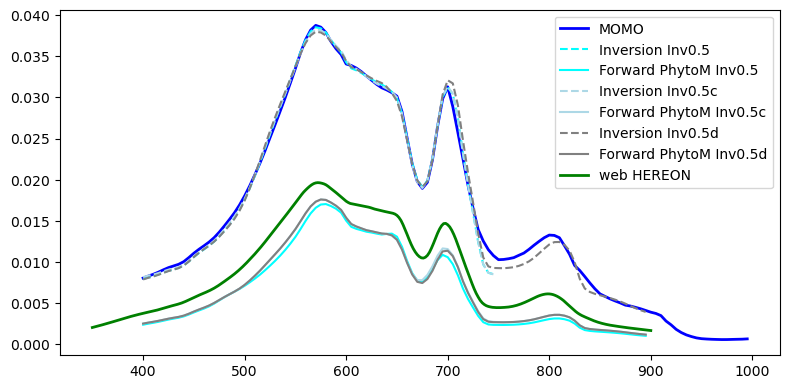

In [14]:
i_spectrum = 90

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(wl, Rrs.iloc[i_spectrum,:], 'b-', linewidth=2, label='MOMO')

for c, versionInv in zip(colorList, versionInvList):
    sim = simDict[versionInv]
    ax.plot(wlinvDict[versionInv], sim.iloc[i_spectrum, 1:].values, '--', color=c, label='Inversion '+versionInv)
    fw = fwDict[versionInv]
    ax.plot(fw_wl, fw.iloc[i_spectrum,:], '-', color=c, label='Forward PhytoM '+versionInv)
    
ax.plot(bi['wavelen'], bi['Rrs_L11'], 'g-', linewidth=2, label='web HEREON')
# ax.plot(gg['wavelen'], gg['Rrs'], 'r-', linewidth=2, label='WASI6')

ax.legend()
fig.tight_layout()
plt.show()

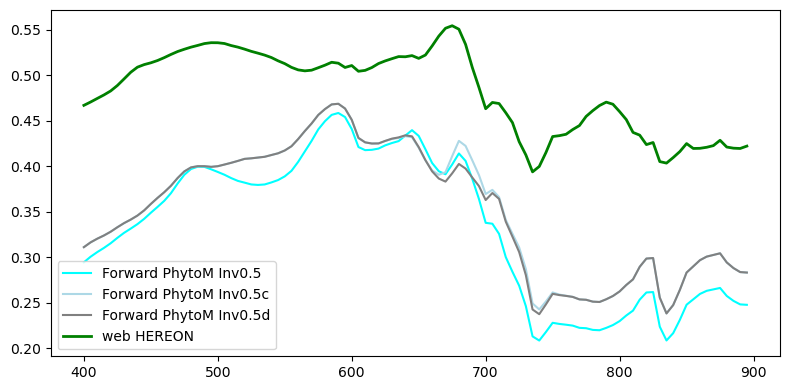

In [166]:
i_spectrum = 90

wlMin, wlMax = (400, 896)

fig, ax = plt.subplots(figsize=(8,4))
ID = np.logical_and(wl>=wlMin, wl<=wlMax)
# ax.plot(wl[ID], Rrs.iloc[i_spectrum,ID], 'b-', linewidth=2, label='MOMO')

for c, versionInv in zip(colorList, versionInvList):
    sim = simDict[versionInv]
    wl_inv = wlinvDict[versionInv]
    # ID_inv = np.logical_and(wl_inv>=wlMin, wl_inv<=wlMax)
    # ax.plot(wl_inv[ID_inv], sim.iloc[i_spectrum, 1:].values[ID_inv] / Rrs.iloc[i_spectrum,ID], '--', color=c, label='Inversion '+versionInv)
    fw = fwDict[versionInv]
    ID_fw = np.logical_and(fw_wl>=wlMin, fw_wl<=wlMax) 
    ax.plot(fw_wl[ID_fw], fw.iloc[i_spectrum,ID_fw] / Rrs.iloc[i_spectrum,ID], '-', color=c, label='Forward PhytoM '+versionInv)


ID_bi = np.logical_and(bi['wavelen'].values>=wlMin, bi['wavelen'].values<=wlMax)
from spectral import BandResampler
band_resampler = BandResampler(bi['wavelen'].values, wl[ID])
bi_res = band_resampler(bi['Rrs_L11'].values)
y =  Rrs.iloc[i_spectrum,:].values[ID]
ax.plot(wl[ID], bi_res /y, 'g-', linewidth=2, label='web HEREON')
# ax.plot(gg['wavelen'], gg['Rrs'], 'r-', linewidth=2, label='WASI6')

ax.legend()
fig.tight_layout()
plt.show()

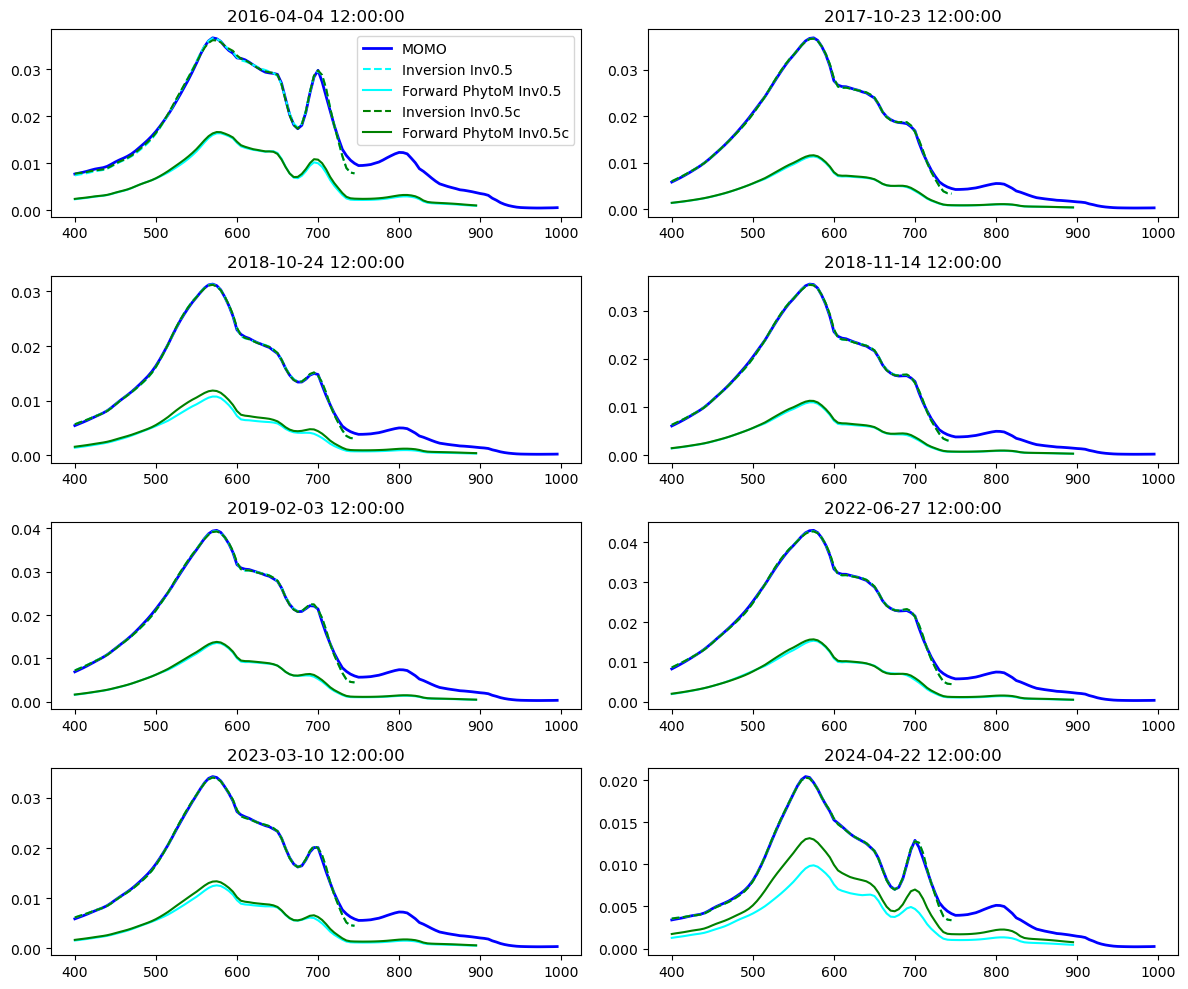

In [139]:

Nx, Ny = (2, 4)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(12, 10))
i_spectrumList = np.sort(np.random.choice(np.arange(0,Rrs.shape[0],1), Nx*Ny, replace=False))
for iy in range(Ny):
    for ix in range(Nx):
        i_spectrum = i_spectrumList[iy*Nx + ix]
        ax[iy, ix].plot(wl, Rrs.iloc[i_spectrum,:], 'b-', linewidth=2, label='MOMO')
        ax[iy, ix].set_title(Rrs.index[i_spectrum])
        for c, versionInv in zip(colorList, versionInvList):
            sim = simDict[versionInv]
            ax[iy, ix].plot(wlinv, sim.iloc[i_spectrum, 1:].values, '--', color=c, label='Inversion '+versionInv)
            fw = fwDict[versionInv]
            ax[iy, ix].plot(fw_wl, fw.iloc[i_spectrum,:], '-', color=c, label='Forward PhytoM '+versionInv)
    
# ax.plot(bi['wavelen'], bi['Rrs_L11'], 'g-', linewidth=2, label='web HEREON')
# ax.plot(gg['wavelen'], gg['Rrs'], 'r-', linewidth=2, label='WASI6')

ax[0,0].legend()
fig.tight_layout()
plt.show()

## Analyse inversion results  
Model absorption and backscattering components from the inversion IOP set.  
Can I reconstruct the inversion simulation spectrum?

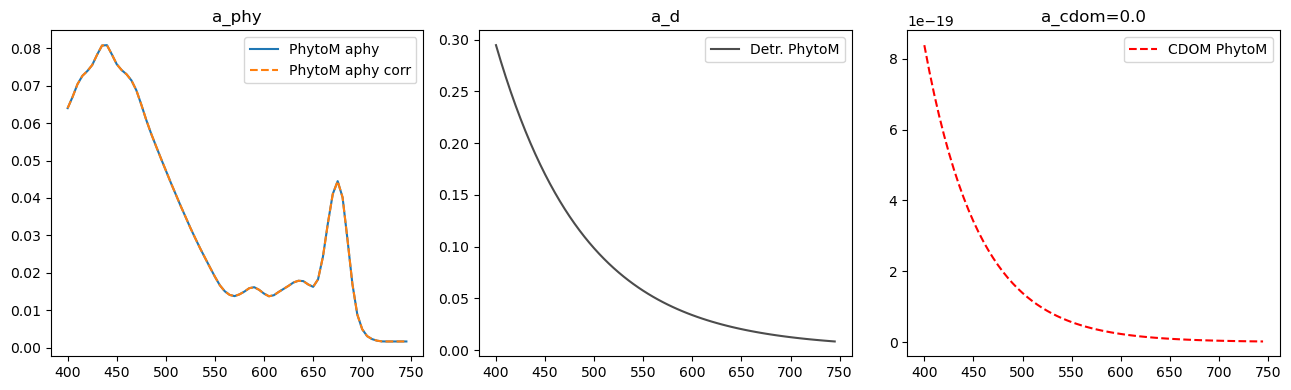

In [46]:
i_spectrum= 234 #0
invVarList = ['C_0', 'C_3', 'C_Y', 'C_ism', 'S_md', 'S_cdom']

# versionInv = 'Inv0.2e'
versionInv = 'Inv0.4'
inv = invDict[versionInv]

fig, ax = plt.subplots(ncols=3, figsize=(13,4))

## absorption phytoplankton -> turns into NaN in the correction!!
a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wlinv) # prototype v2, PACEv2
a_phy_res = absorption.a_phy(wavelengths=wlinv, C_0=inv['C_0'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=inv['C_3'].iloc[i_spectrum], 
                             C_4=0, C_5=0, C_6=0, C_7=0, a_i_spec_res=a_i_spec_res)
lambda_0_phy=676.
A=0.0237
E0=1.
E1=0.8987
a_phy_corr = absorption.correct_a_phy(a_phy_res=a_phy_res, wavelengths=wlinv, C_phy=inv['C_phy'].iloc[i_spectrum], 
                                      A=A, E0=E0, E1=E1, lambda_0_phy=lambda_0_phy, interpolate=True)

# print(a_phy_corr)
ax[0].plot(wlinv, a_phy_res, '-', label='PhytoM aphy')
ax[0].plot(wlinv, a_phy_corr, '--', label='PhytoM aphy corr')
ax[0].legend()
ax[0].set_title('a_phy')

## a_d
anap_spec440 = insitu['anap_spec(440) [m2 g-1]'].iloc[i_spectrum]
S_xd = insitu['Snap [1/nm]'].iloc[i_spectrum]
a_md_spec_res = absorption.a_xd_spec(wlinv, anap_spec440, S_xd, lambda_0=440.)

a_d_res = absorption.a_d(wavelengths=wlinv, 
        C_ism=inv['C_ism'].iloc[i_spectrum], 
        C_phy=inv['C_phy'].iloc[i_spectrum],
        A_bd=0.3893e-3, 
        S_bd=15.7621e-3, 
        C_bd= 0.9994e-3, 
        lambda_0_bd=550., 
        a_md_spec_res=a_md_spec_res, # default: []
        a_bd_spec_res=[])

ax[1].plot(wlinv, a_d_res, '-', color='black', alpha=0.7, label='Detr. PhytoM')
ax[1].legend()
ax[1].set_title('a_d')

## a_cdom
acdom_res = absorption.a_Y(C_Y=inv['C_Y'].iloc[i_spectrum], wavelengths=wlinv, S=inv['S_cdom'].iloc[i_spectrum], lambda_0=440.) # actual
ax[2].plot(wlinv, acdom_res , '--', color='red', label='CDOM PhytoM')
ax[2].set_title('a_cdom=' + str(np.round(inv['C_Y'].iloc[i_spectrum], 3)))

ax[2].legend()
fig.tight_layout()
plt.show()


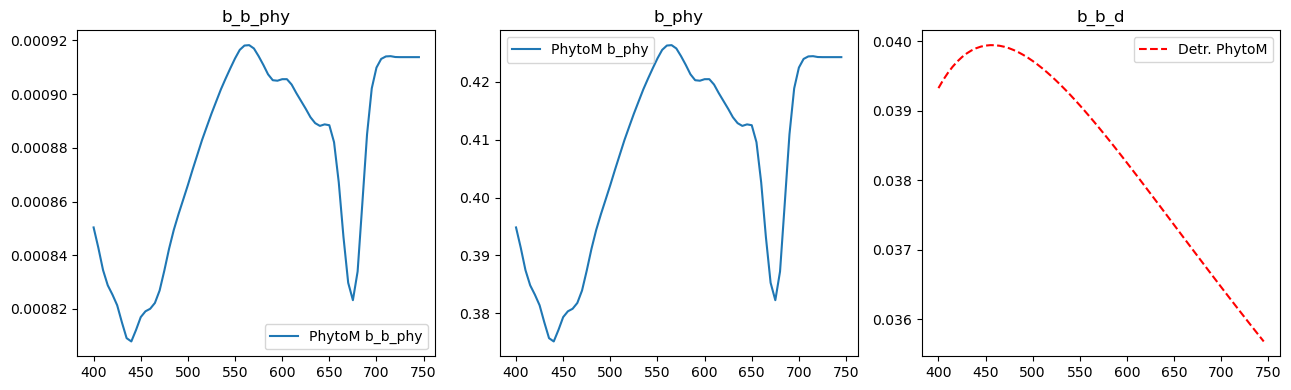

In [44]:
i_spectrum = 234 #0

fig, ax = plt.subplots(ncols=3, figsize=(13,4))

## backscattering
b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wlinv) # prototype v2, PACEv2
b_b_phy_res = backscattering.b_bphy_hereon(wavelengths=wlinv, C_0=inv['C_0'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=inv['C_3'].iloc[i_spectrum],
                             C_4=0, C_5=0, C_6=0, C_7=0, b_i_spec_res=b_i_spec_res)

ax[0].plot(wlinv, b_b_phy_res, '-', label='PhytoM b_b_phy')
ax[0].legend()
ax[0].set_title('b_b_phy')

## scattering:
b_phy_res = scattering.b_phy(wavelengths=wlinv,  C_0=inv['C_0'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=inv['C_3'].iloc[i_spectrum], 
                             C_4=0, C_5=0, C_6=0, C_7=0, b_i_spec_res=b_i_spec_res)

ax[1].plot(wlinv, b_phy_res, '-', label='PhytoM b_phy')
ax[1].legend()
ax[1].set_title('b_phy')

## 	Backscattering Detritus:
anap_spec440 = insitu['anap_spec(440) [m2 g-1]'].iloc[i_spectrum]
S_xd = insitu['Snap [1/nm]'].iloc[i_spectrum]
a_md_spec_res = absorption.a_xd_spec(wlinv, anap_spec440, S_xd, lambda_0=440.)

a_d_res = absorption.a_d(wavelengths=wlinv, 
        C_ism=inv['C_ism'].iloc[i_spectrum].round(3), 
        C_phy=inv['C_phy'].iloc[i_spectrum].round(3),
        A_bd=0.3893e-3, 
        S_bd=15.7621e-3, 
        C_bd= 0.9994e-3, 
        lambda_0_bd=550., 
        a_md_spec_res=a_md_spec_res, # default: []
        a_bd_spec_res=[])

c_d_res = attenuation.c_d(wavelengths=wlinv, 
                        C_ism=inv['C_ism'].iloc[i_spectrum], 
                          C_phy=inv['C_phy'].iloc[i_spectrum],
                          a_md_spec_res=a_md_spec_res,
                          a_bd_spec_res=[])

b_d_res = scattering.b(a_d_res, c_d_res)
b_bd_res = backscattering.b_bd(b_d_res, b_ratio_d=inv['b_ratio_d'].iloc[i_spectrum])
# b_bd(b_d_res, b_ratio_d=b_ratio_d)

ax[2].plot(wlinv, b_bd_res , '--', color='red', label='Detr. PhytoM')
ax[2].set_title('b_b_d')

ax[2].legend()
fig.tight_layout()
plt.show()

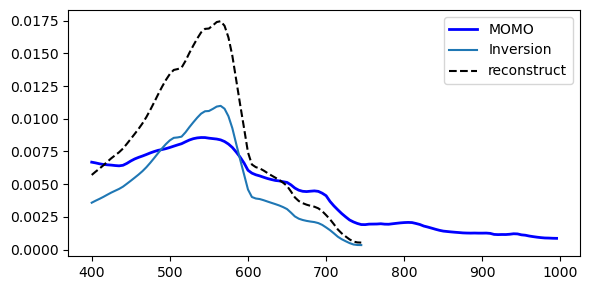

In [45]:
b_bp_res = b_bd_res + b_b_phy_res
b_bw_res = resampling.resample_b_bw(wavelengths=wlinv)
b_b_res = b_bp_res + b_bw_res

T_W_0 = 20.
a_w_res = absorption.a_w(wavelengths=wlinv) #+ (insitu['Temp °C'].iloc[i_spectrum] - T_W_0) * absorption.da_W_div_dT(wavelengths=wlinv)
a_res = a_phy_corr  + a_d_res + acdom_res + a_w_res #a_phy_corr

Rrs_ = lee.R_rs_deep(a=a_res, 
                   b_b=b_b_res, 
                   b_bp=b_bp_res, 
                   b_bw=b_bw_res)

fig, ax = plt.subplots(figsize=(6,3))
sim = simDict[versionInv]
ax.plot(wl, Rrs.iloc[i_spectrum,:], 'b-', linewidth=2, label='MOMO')
ax.plot(wlinv, sim.iloc[i_spectrum, 1:].values, '-', label='Inversion')
ax.plot(wlinv, Rrs_, 'k--', label='reconstruct')
ax.legend()
fig.tight_layout()
plt.show()

In [131]:
bi.columns.values

array(['wavelen', 'aph', 'ad', 'acdom', 'bph', 'bd', 'aw', 'bw', 'ap',
       'agp', 'bp', 'at', 'bt', 'bbph', 'bbd', 'bbp', 'bbw', 'bbt',
       'Rrs_L11', 'Rrs_AM03'], dtype=object)

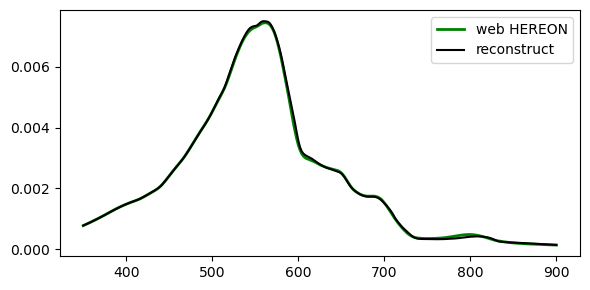

In [14]:
## check webHEREON
b_bp_res = bi.bbd + bi.bbph
b_bw_res = resampling.resample_b_bw(wavelengths=bi.wavelen.values)
b_b_res = b_bp_res + b_bw_res

T_W_0 = 20.
a_w_res = absorption.a_w(wavelengths=bi.wavelen.values) #+ (insitu['Temp °C'].iloc[i_spectrum] - T_W_0) * absorption.da_W_div_dT(wavelengths=wlinv)
a_res = bi.aph  + bi.ad + bi.acdom + a_w_res 

Rrs_ = lee.R_rs_deep(a=a_res, 
                   b_b=b_b_res, 
                   b_bp=b_bp_res, 
                   b_bw=b_bw_res)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(bi['wavelen'], bi['Rrs_L11'], 'g-', linewidth=2, label='web HEREON')
ax.plot(bi['wavelen'], Rrs_, 'k-', label='reconstruct')
ax.legend()
fig.tight_layout()
plt.show()

## Compare absorption components  
- a_phy: small difference ?
- a_d: ***no difference***, if default values of Bi-Model are used. Our anap_spec and S_nap is different!
- a_cdom: difference, even for default values!

Chlg [µg/l]                37.930000
Ckie [µg/l]                28.270000
Cbl [µg/l]                  0.000000
ag(440) [1/m]               0.646944
Sg [1/nm]                   0.017000
TSPM [mg/l]                25.517644
NAP [mg/l]                 23.658829
anap_spec(440) [m2 g-1]     0.036170
Snap [1/nm]                 0.009300
Name: 2015-04-04 00:00:00, dtype: float64
anap_spec440 0.03617 S_nap 0.0093


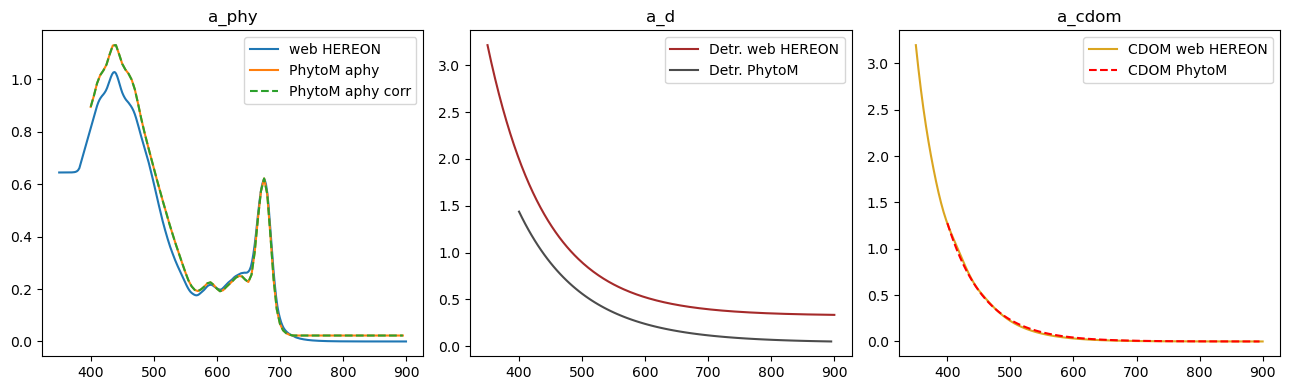

In [17]:
i_spectrum = 90 #0

varList = ['Chlg [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]', 'anap_spec(440) [m2 g-1]', 'Snap [1/nm]']
print(insitu[varList].iloc[i_spectrum])

fig, ax = plt.subplots(ncols=3, figsize=(13,4))
ax[0].plot(bi['wavelen'], bi['aph'], '-', label='web HEREON')

a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wlinv) # prototype v2, PACEv2
a_phy_res = absorption.a_phy(wavelengths=wlinv, C_0=insitu['Ckie [µg/l]'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=insitu['Cbl [µg/l]'].iloc[i_spectrum], 
                             C_4=0, C_5=0, C_6=0, C_7=0, a_i_spec_res=a_i_spec_res)
lambda_0_phy=676.
A=0.0237
E0=1.
E1=0.8987
a_phy_corr = absorption.correct_a_phy(a_phy_res=a_phy_res, wavelengths=wlinv, C_phy=insitu['Chlg [µg/l]'].iloc[i_spectrum], 
                                      A=A, E0=E0, E1=E1, lambda_0_phy=lambda_0_phy, interpolate=True)

ax[0].plot(wlinv, a_phy_res, '-', label='PhytoM aphy')
ax[0].plot(wlinv, a_phy_corr, '--', label='PhytoM aphy corr')
ax[0].legend()
ax[0].set_title('a_phy')

## a_d, a_cdom: ad 	acdom 	bph 	bd
ax[1].plot(bi['wavelen'], bi['ad'], '-', color='brown', label='Detr. web HEREON')

anap_spec440 = insitu['anap_spec(440) [m2 g-1]'].iloc[i_spectrum]
S_xd = insitu['Snap [1/nm]'].iloc[i_spectrum]
print('anap_spec440', anap_spec440 , 'S_nap', S_xd)
a_md_spec_res = absorption.a_xd_spec(wlinv, anap_spec440, S_xd, lambda_0=440.)

a_d_res = absorption.a_d(wavelengths=wlinv, 
        C_ism=insitu['NAP [mg/l]'].iloc[i_spectrum], 
        C_phy=insitu['Chlg [µg/l]'].iloc[i_spectrum],
        A_bd=0.3893e-3, 
        S_bd=15.7621e-3, 
        C_bd= 0.9994e-3, 
        lambda_0_bd=550., 
        a_md_spec_res=a_md_spec_res, # default: []
        a_bd_spec_res=[])

ax[1].plot(wlinv, a_d_res, '-', color='black', alpha=0.7, label='Detr. PhytoM')
ax[1].legend()
ax[1].set_title('a_d')

## a_cdom
ax[2].plot(bi['wavelen'], bi['acdom'], '-', color='goldenrod', label='CDOM web HEREON')
acdom_res = absorption.a_Y(C_Y=insitu['ag(440) [1/m]'].iloc[i_spectrum], wavelengths=wlinv, S=insitu['Sg [1/nm]'].iloc[i_spectrum], lambda_0=440.) # actual
# acdom_res = absorption.a_Y(C_Y=insitu['ag(440) [1/m]'].iloc[i_spectrum], wavelengths=wlinv) # default
ax[2].plot(wlinv, acdom_res , '--', color='red', label='CDOM PhytoM')
ax[2].set_title('a_cdom')

ax[2].legend()
fig.tight_layout()
plt.show()

## Compare scattering components  
- b_b_phy: different, why?
- b_phy: conversion is strange!!
- b_b_d: identical, if default values are used. 

Chlg [µg/l]                37.930000
Ckie [µg/l]                28.270000
Cbl [µg/l]                  0.000000
ag(440) [1/m]               0.646944
Sg [1/nm]                   0.017000
TSPM [mg/l]                25.517644
NAP [mg/l]                 23.658829
anap_spec(440) [m2 g-1]     0.036170
Snap [1/nm]                 0.009300
Name: 2015-04-04 00:00:00, dtype: float64
[1.28278891 1.29418077 1.30126712]
[1.46176763 1.47474892 1.48282398]


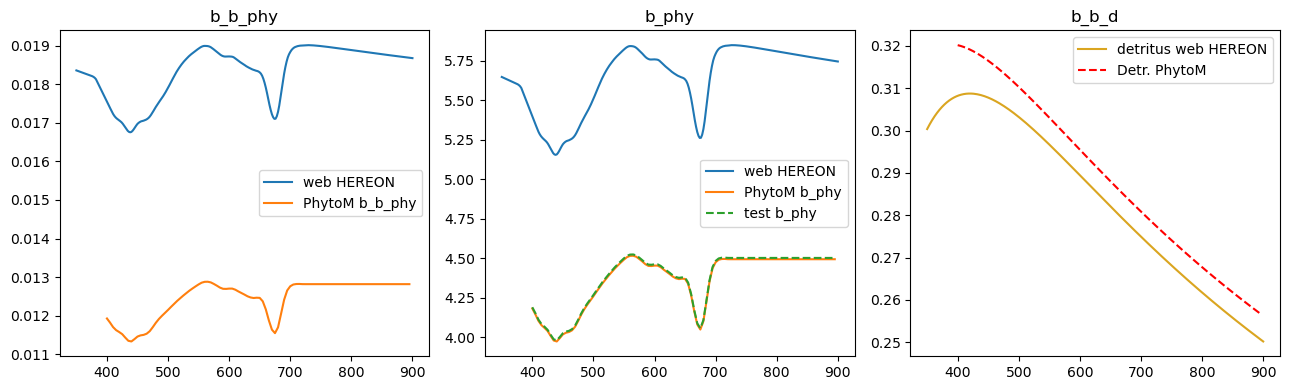

In [18]:
i_spectrum = 90 #234 #0

varList = ['Chlg [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]', 'anap_spec(440) [m2 g-1]', 'Snap [1/nm]']
print(insitu[varList].iloc[i_spectrum])

fig, ax = plt.subplots(ncols=3, figsize=(13,4))

## backscattering
ax[0].plot(bi['wavelen'], bi['bbph'], '-', label='web HEREON')

b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wlinv) # prototype v2, PACEv2
b_b_phy_res = backscattering.b_bphy_hereon(wavelengths=wlinv, C_0=insitu['Ckie [µg/l]'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=insitu['Cbl [µg/l]'].iloc[i_spectrum], 
                             C_4=0, C_5=0, C_6=0, C_7=0, b_i_spec_res=b_i_spec_res)

ax[0].plot(wlinv, b_b_phy_res, '-', label='PhytoM b_b_phy')
ax[0].legend()
ax[0].set_title('b_b_phy')


## scattering:
ax[1].plot(bi['wavelen'], bi['bph'], '-', label='web HEREON')
b_phy_res = scattering.b_phy(wavelengths=wlinv, C_0=insitu['Ckie [µg/l]'].iloc[i_spectrum], C_1=0, C_2=0, 
                             C_3=insitu['Cbl [µg/l]'].iloc[i_spectrum], 
                             C_4=0, C_5=0, C_6=0, C_7=0, b_i_spec_res=b_i_spec_res)

gamma_i = np.array([0.8943513, 0.8938004, 0.8938008, 0.8938008, 0.89379981, 0.8938001, 0.893800, 0.8937999])
b_phy_test = insitu['Ckie [µg/l]'].iloc[i_spectrum]**gamma_i[0] *b_i_spec_res[:,0] + insitu['Cbl [µg/l]'].iloc[i_spectrum]**gamma_i[3]*b_i_spec_res[:,3]

ax[1].plot(wlinv, b_phy_res, '-', label='PhytoM b_phy')
ax[1].plot(wlinv, b_phy_test, '--', label='test b_phy')

from spectral import BandResampler
band_resampler = BandResampler(bi['wavelen'].values, wlinv) 
bi_bph_res = band_resampler(np.asarray(bi['bph'].values))
print(np.percentile(bi_bph_res / b_phy_res, [5, 50, 95] ))

bi_bbph_res = band_resampler(np.asarray(bi['bbph'].values))
print(np.percentile(bi_bbph_res / b_b_phy_res, [5, 50, 95] ))


#not correct
# c_bd_ = attenuation.c_bd(wavelengths=wlinv, C_phy=insitu['Chlg [µg/l]'].iloc[i_spectrum])
# ax[1].plot(wlinv, c_bd_ - a_phy_res, '--', label='from c_bd')

ax[1].legend()
ax[1].set_title('b_phy')

## 	Backscattering Detritus:
anap_spec440 = insitu['anap_spec(440) [m2 g-1]'].iloc[i_spectrum]
S_xd = insitu['Snap [1/nm]'].iloc[i_spectrum]
a_md_spec_res = absorption.a_xd_spec(wlinv, anap_spec440, S_xd, lambda_0=440.)

a_d_res = absorption.a_d(wavelengths=wlinv, 
        C_ism=insitu['NAP [mg/l]'].iloc[i_spectrum], 
        C_phy=insitu['Chlg [µg/l]'].iloc[i_spectrum],
        A_bd=0.3893e-3, 
        S_bd=15.7621e-3, 
        C_bd= 0.9994e-3, 
        lambda_0_bd=550., 
        a_md_spec_res= a_md_spec_res, # default: []
        a_bd_spec_res=[])

c_d_res = attenuation.c_d(wavelengths=wlinv, 
                        C_ism=insitu['NAP [mg/l]'].iloc[i_spectrum], 
                          C_phy=insitu['Chlg [µg/l]'].iloc[i_spectrum],
                          a_md_spec_res=a_md_spec_res,
                          a_bd_spec_res=[])

b_d_res = scattering.b(a_d_res, c_d_res)
b_bd_res = backscattering.b_bd(b_d_res)

ax[2].plot(bi['wavelen'], bi['bbd'], '-', color='goldenrod', label='detritus web HEREON')
ax[2].plot(wlinv, b_bd_res , '--', color='red', label='Detr. PhytoM')
ax[2].set_title('b_b_d')

ax[2].legend()
fig.tight_layout()
plt.show()

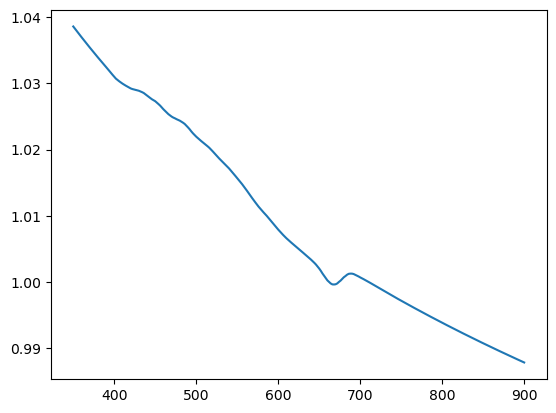

In [39]:
plt.plot(bi['wavelen'], bi['bph'] + bi['aph'], '-', label='bph+aph web HEREON')
plt.show()

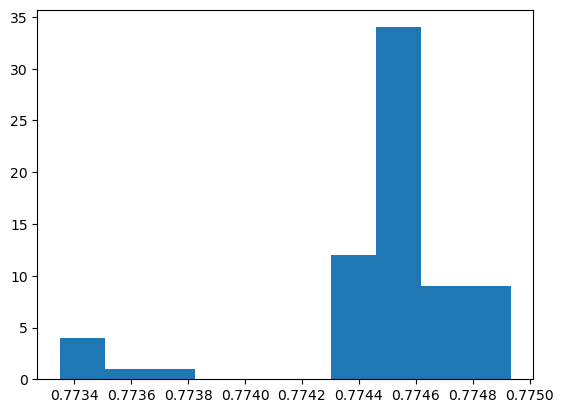

array([0.00258, 0.00258, 0.00258])

In [18]:
from spectral import BandResampler

band_resampler = BandResampler(bi['wavelen'].values, wlinv)
bi_bph = band_resampler(bi["bbph"])
plt.hist( b_b_phy_res/bi_bph)
plt.show()

np.percentile(bi["bbph"].values/bi["bph"].values, [1, 50, 99])

## Analyse Bi web model - Scattering    
Backscattering ratio per group  
Model run with one component conc=1µg/l

In [12]:
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\webHEREON\\"
fnames = os.listdir(path)
phytoTypes = ['Brown', 'Green', 'Crypt', 'CyanoB', 'CyanoR', 'Cocco', 'Case1']
phyto_b = pd.DataFrame()
for phyto in phytoTypes:
    fname = [fn for fn in fnames if phyto in fn]
    d = pd.read_csv(path + fname[0], header=0)
    phyto_b['bbph_'+phyto] = d["bbph"].values
    phyto_b['bph_'+phyto] = d["bph"].values
    
    print(phyto, np.percentile(d["bbph"].values/d["bph"].values, [1, 50, 99]))

Brown [0.002 0.002 0.002]
Green [0.007 0.007 0.007]
Crypt [0.002 0.002 0.002]
CyanoB [0.003 0.003 0.003]
CyanoR [0.003 0.003 0.003]
Cocco [0.007 0.007 0.007]
Case1 [0.007 0.007 0.007]


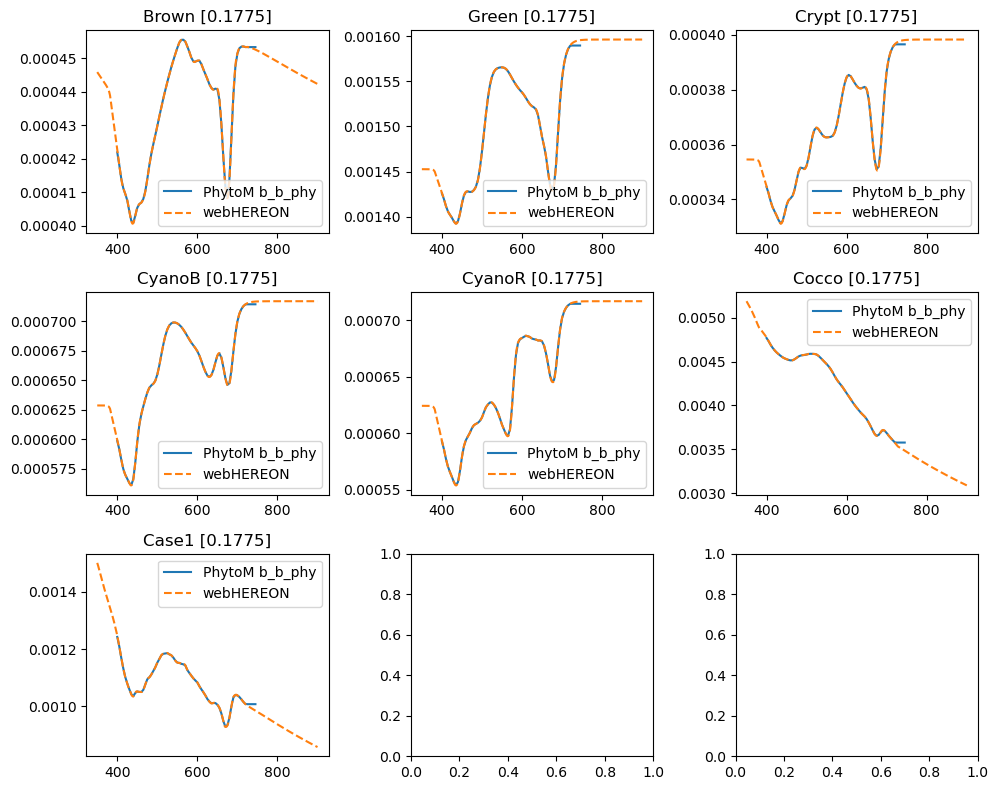

In [15]:
b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wlinv) # prototype v2, PACEv2

Nx, Ny = (3,3)
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10,8))
ix, iy = (0,0)
for i, phyto in enumerate(phytoTypes):
    
    b_b_phy_res = backscattering.b_bphy_hereon(wavelengths=wlinv, 
                                               C_0= float(phyto==phytoTypes[0]), 
                                               C_1= float(phyto==phytoTypes[1]), 
                                               C_2= float(phyto==phytoTypes[2]), 
                                               C_3= float(phyto==phytoTypes[3]), 
                                               C_4= float(phyto==phytoTypes[4]),
                                               C_5= float(phyto==phytoTypes[5]),
                                               C_6= 0.,
                                               C_7= float(phyto==phytoTypes[6]),
                                               b_i_spec_res=b_i_spec_res)
    ax[iy, ix].plot(wlinv, b_b_phy_res, '-', label='PhytoM b_b_phy')
    ax[iy, ix].plot(bi['wavelen'].values, phyto_b['bbph_'+phyto], '--', label='webHEREON')

    ### identical ###
    # b_phy_res = scattering.b_phy(wavelengths=wlinv, 
    #                            C_0= float(phyto==phytoTypes[0]), 
    #                            C_1= float(phyto==phytoTypes[1]), 
    #                            C_2= float(phyto==phytoTypes[2]), 
    #                            C_3= float(phyto==phytoTypes[3]), 
    #                            C_4= float(phyto==phytoTypes[4]),
    #                            C_5= float(phyto==phytoTypes[5]),
    #                            C_6= 0.,
    #                            C_7= float(phyto==phytoTypes[6]),
    #                            b_i_spec_res=b_i_spec_res)

    # if phyto=='Brown':
    #     print(b_phy_res[wlinv==400])
    # ax[iy, ix].plot(wlinv, b_phy_res, '-', label='PhytoM b_phy')
    # ax[iy, ix].plot(bi['wavelen'].values, phyto_b['bph_'+phyto], '--', label='webHEREON')
    
    ax[iy, ix].legend()
    ax[iy, ix].set_title(phyto+ ' ' + str(np.round(b_phy_res[wlinv==400],4)))
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1

fig.tight_layout()
plt.show()

0.89379993156262


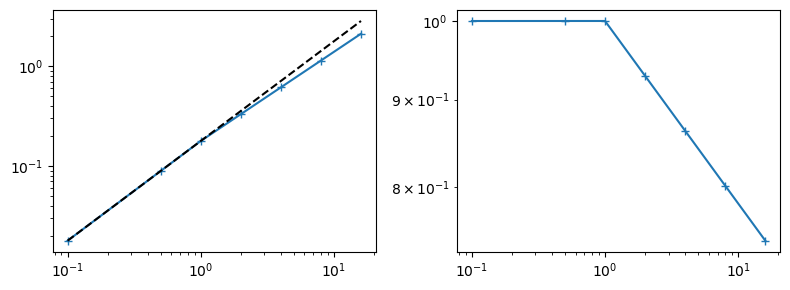

In [25]:
#at 400
conc = np.asarray([0.1, 0.5, 1, 2, 4, 8, 16])
brown_bphy_web = np.asarray([0.021127, 0.105634, 0.21094613, 0.392551, 0.729385, 1.355243, 2.518128])
green_bphy_web = np.asarray([0.020384, 0.101918, 0.203835, 0.378739, 0.703721, 1.307559, 2.429527])
crypt_bphy_web = np.array([0.017243,0.086216, 0.172431 , 0.320389, 0.595302, 1.106110, 2.055222])
cyanoB_bphy_web = np.array([0.019985, 0.099925, 0.199849, 0.371333, 0.689960, 1.281990, 2.382020 ])
cyanoR_bphy_web = np.array([0.019796 	,0.098981 ,0.197963 ,0.367828 ,0.683447,1.269889 ,2.359534 	])
cocco_bphy_web = np.array([0.068214, 0.341071, 0.682141, 1.267462 ,2.355025 ,4.375786, 8.130490 ])
case1_bphy_web = np.array([0.017821, 0.089107 , 0.178215, 0.331135, 0.615269, 1.143210, 2.124157])

def plot_and_analyse(conc, bphy_web):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
    ax[0].loglog(conc, bphy_web, '-+')
    ax[0].plot((np.min(conc),np.max(conc)), bphy_web[conc==1]*np.array((np.min(conc),np.max(conc))) , 'k--')
    ax[1].loglog(conc, bphy_web/(bphy_web[conc==1]*conc), '-+')
    
    slope = np.diff(np.log(bphy_web))/np.diff(np.log(conc))
    print(np.mean(slope[conc[:-1]>=1]))
    
    fig.tight_layout()
    plt.show()

plot_and_analyse(conc, case1_bphy_web)

## Rrs withouth fluoresence

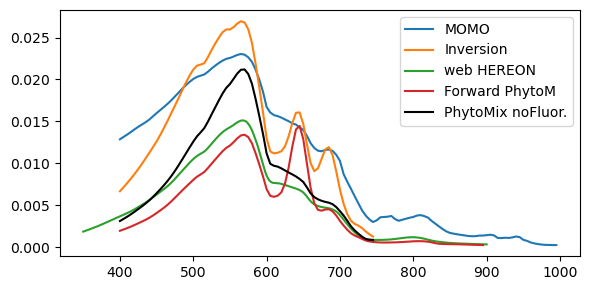

In [66]:
b_bp_res = b_bd_res + b_b_phy_res
b_bw_res = resampling.resample_b_bw(wavelengths=wlinv)
b_b_res = b_bp_res + b_bw_res

T_W_0 = 20.
a_w_res = absorption.a_w(wavelengths=wlinv) #+ (insitu['Temp °C'].iloc[i_spectrum] - T_W_0) * absorption.da_W_div_dT(wavelengths=wlinv)
a_res = a_phy_corr + a_d_res + acdom_res + a_w_res

Rrs_ = lee.R_rs_deep(a=a_res, 
                   b_b=b_b_res, 
                   b_bp=b_bp_res, 
                   b_bw=b_bw_res)

i_spectrum = 0
# fig, ax = plt.subplots(figsize=(6,3))
# ax.plot(bi['wavelen'], bi['bbp'], '-', label='web HEREON')
# ax.plot(wlinv, b_bp_res, '-', label='Forward PhytoM')

# i_spectrum = 0
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(wl, Rrs.iloc[i_spectrum,:], '-', label='MOMO')
sim = simDict[versionInvList[0]]
ax.plot(wlinv, sim.iloc[i_spectrum, 1:].values, '-', label='Inversion')
ax.plot(bi['wavelen'], bi['Rrs_L11'], '-', label='web HEREON')
ax.plot(fw_wl, fw.iloc[i_spectrum,:], '-', label='Forward PhytoM')
ax.plot(wlinv, Rrs_, 'k-', label='PhytoMix noFluor.')
ax.legend()
fig.tight_layout()
plt.show()

## Backscattering Phytoplankton  
Concentration of two groups at 2 µg/l.
Brown group, Cyano_blue group  

In [73]:
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\webHEREON\\"
fnames = os.listdir(path)
fname = [fn for fn in fnames if 'c0_2' in fn]
print(fname)
d = pd.read_csv(path + fname[0], header=0)

['IOP_spectra_outputs_c0_2_c3_2_cx_0_cy_0.csv']


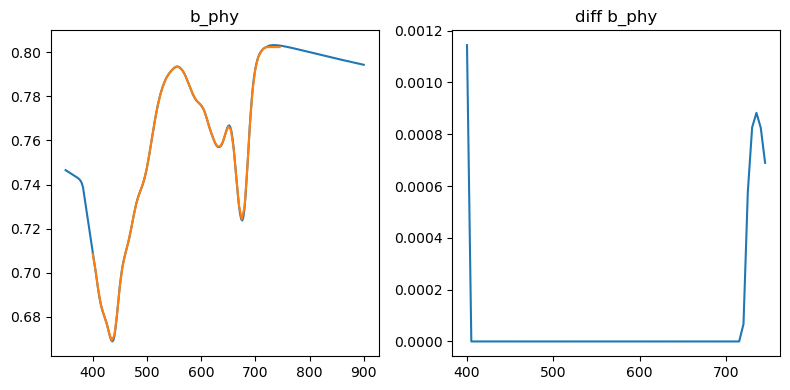

In [76]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
ax[0].plot(d['wavelen'].values, d['bph'].values, '-', label='webHEREON')

b_phy_res = scattering.b_phy(wavelengths=wlinv, C_0=2., C_1=0, C_2=0, 
                             C_3=2., 
                             C_4=0, C_5=0, C_6=0, C_7=0, b_i_spec_res=b_i_spec_res)
ax[0].plot(wlinv, b_phy_res , '-', label='phytomix')
ax[0].set_title('b_phy')

band_resampler = BandResampler(d['wavelen'].values, wlinv)
bi_bph = band_resampler(d["bph"])

ax[1].plot(wlinv, bi_bph - b_phy_res, '-')
ax[1].set_title('diff b_phy')

fig.tight_layout()
plt.show()


## Backscattering water

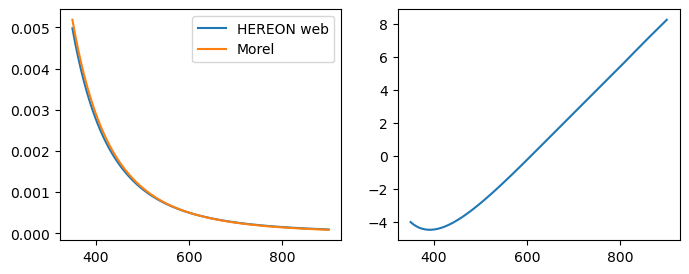

In [286]:
b_bw = resampling.resample_b_bw(wavelengths=bi.wavelen)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
ax[0].plot(bi.wavelen, bi.bbw, '-', label='HEREON web')
ax[0].plot(bi.wavelen, b_bw, '-', label='Morel')
ax[0].legend()
ax[1].plot(bi.wavelen, (bi.bbw-b_bw)/b_bw*100., '-')
plt.show()

# Analyse Vörtsjärv  
compare:
- insitu spectra
- MOMO spectra
- inversion results
- forward HEREON spectra

In [2]:
## Simulated spectra MOMO Rrs
# momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\" + position+"\\"
locName =  "vortsjarv" #"oder-frankfurt" # 'finnmaid-helsinki'
partFname = "AQUATIME_D2.1.0_RD-" + locName

def read_spectra(path, fname):
    Rrs = pd.read_csv(path + fname, header=0)
    Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum', 'QWIP']
    varList = [v for v in varList if v in Rrs.columns.values]
    
    owtDF = Rrs[varList].copy()
    Rrs = Rrs.drop(columns=varList)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    wlstr = [str(a) for a in wl]
    return Rrs, wl, wlstr, owtDF

momopath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\"+locName+"\\"

fname = os.listdir(momopath)
fname = [fn for fn in fname if 'Rrs_v0.3' in fn and 'fluo' in fn]
# AQUATIME_D2.1.0_RD-vortsjarv_irregular_fluo-chime-simulated-5nm-Rrs_v0.3
Rrs_glint, wl, wlstr, owtDF_glint = read_spectra(momopath, fname[0])

fname = os.listdir(momopath)
fname = [fn for fn in fname if 'RrsNoGlint_v0.3' in fn and 'fluo' in fn]
Rrs_noglint, wl, wlstr, owtDF_noglint = read_spectra(momopath, fname[0])

In [3]:
# read insitu spectra
## CAUTION: these are water leaving reflectances! Divide by pi to convert to Rrs
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\Case_Study_3\Vortsjarv\Hyperspectral data\\"
insituRrs = pd.read_csv(path+ "Hypstar_radiometric_23-24.csv", header=0)
datetimeStr = [str(dt) + ' 12:00:00' for dt in insituRrs['Date'].values]
insituRrs['date'] = pd.to_datetime(datetimeStr, format= '%Y%m%d %H:%M:%S')
insituRrs = insituRrs.set_index('date')
wl_ins = np.asarray([float(a) for a in insituRrs.columns.values[1:]])
insituRrs = insituRrs.drop(columns=['Date'])
insituRrs.loc[:,:] = insituRrs.loc[:,:].values / np.pi
insituRrs

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_7472\388053000.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  insituRrs['date'] = pd.to_datetime(datetimeStr, format= '%Y%m%d %H:%M:%S')


,350.44504886539,350.909292188195,351.37360136996,351.837976374923,352.302417167244,352.766923710995,353.231495970167,353.696133908665,354.160837490312,354.625606678847,...,1095.5527552491,1096.02645598481,1096.50007069826,1096.97359922605,1097.44704140472,1097.92039707073,1098.39366606044,1098.86684821013,1099.33994335601,1099.81295133418
date,,,,,,,,,,,,,,,,,,,,,
2023-05-07 12:00:00,0.001467,0.001430,0.001458,0.001390,0.001451,0.001427,0.001412,0.001391,0.001400,0.001365,...,0.000577,0.000424,0.000067,0.000314,0.000676,0.000235,0.000390,0.000428,0.000244,0.000804
2023-05-08 12:00:00,0.001228,0.001242,0.001273,0.001149,0.001215,0.001182,0.001200,0.001182,0.001177,0.001181,...,0.000184,-0.000239,0.000576,0.000418,0.000237,0.000288,0.001223,-0.000171,0.000339,-0.000036
2023-05-10 12:00:00,0.001221,0.001164,0.001177,0.001165,0.001167,0.001170,0.001186,0.001093,0.001165,0.001105,...,0.000587,0.000189,0.000518,0.000133,0.000316,0.000213,0.000267,-0.000081,0.000405,0.000541
2023-05-11 12:00:00,0.001185,0.001165,0.001142,0.001144,0.001152,0.001124,0.001151,0.001083,0.001088,0.001078,...,0.000565,0.000219,0.000166,0.000044,0.000554,0.000114,0.000554,-0.000044,0.000809,-0.000546
2023-05-12 12:00:00,0.001383,0.001302,0.001349,0.001280,0.001331,0.001326,0.001283,0.001279,0.001255,0.001225,...,0.000080,-0.000456,0.000531,0.000106,0.000484,-0.000199,0.000077,0.000331,0.000173,-0.000020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-19 12:00:00,0.002018,0.001913,0.001890,0.001726,0.001923,0.001821,0.001828,0.001747,0.001792,0.001831,...,0.000981,0.002102,0.001227,0.001606,0.001027,0.001527,0.001377,0.003079,0.001370,0.003087
2024-10-20 12:00:00,0.001907,0.001911,0.001858,0.001861,0.001888,0.001697,0.001818,0.001873,0.001773,0.001704,...,0.001848,0.001090,0.000806,0.000293,0.001072,0.000239,0.001158,-0.000254,0.001465,0.001107
2024-10-29 12:00:00,0.002628,0.002654,0.002565,0.002618,0.002587,0.002757,0.002613,0.002620,0.002478,0.002546,...,0.002024,-0.000674,0.001438,0.000598,0.001832,0.000031,0.000010,0.000810,0.001585,0.001117


In [4]:
## read forward simulations Vortsjarv ##
## TODO: Forward simulations with angle dependency ##
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\FullInversion\\bio-optics_forward\\"
fname = "SimRrs_InsituForward_HEREONorig_HEREONgoldinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_pyhajarvi_allOWTs_Inv0_Inv0.1.txt" # naming ??
forward = pd.read_csv(path+fname, sep='\t', header=0)

iop_path = 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\'
datasetNameIOP = 'vortsjarv'
fname = os.listdir(iop_path)
fname = [fn for fn in fname if fn.startswith(datasetNameIOP) and 'v0.3' in fn]  # Helsinki: 'IOP' in fn and ... 'v0.1b'
iop_insitu = pd.read_csv(iop_path+ fname[0], sep=',')
iop_insitu['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
iop_insitu = iop_insitu.set_index('date')

forward['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
forward = forward.set_index('date')
wl_fw = np.asarray([float(a) for a in forward.columns.values])
wl_fw
# forward
# iop_insitu

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_7472\2972302447.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forward['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])


array([400., 405., 410., 415., 420., 425., 430., 435., 440., 445., 450.,
       455., 460., 465., 470., 475., 480., 485., 490., 495., 500., 505.,
       510., 515., 520., 525., 530., 535., 540., 545., 550., 555., 560.,
       565., 570., 575., 580., 585., 590., 595., 600., 605., 610., 615.,
       620., 625., 630., 635., 640., 645., 650., 655., 660., 665., 670.,
       675., 680., 685., 690., 695., 700., 705., 710., 715., 720., 725.,
       730., 735., 740., 745., 750., 755., 760., 765., 770., 775., 780.,
       785., 790., 795., 800., 805., 810., 815., 820., 825., 830., 835.,
       840., 845., 850., 855., 860., 865., 870., 875., 880., 885., 890.,
       895.])

In [5]:
ID = np.intersect1d(insituRrs.index, Rrs_glint.index)
ID

array(['2023-06-15T12:00:00.000000', '2023-08-16T12:00:00.000000',
       '2024-07-22T12:00:00.000000', '2024-08-15T12:00:00.000000',
       '2024-09-16T12:00:00.000000', '2024-10-17T12:00:00.000000'],
      dtype='datetime64[us]')

In [6]:
Rrs_glint_sel = Rrs_glint.loc[ID]
Rrs_noglint_sel = Rrs_noglint.loc[ID]
insituRrs_sel = insituRrs.loc[ID]
forward_sel = forward.loc[ID]
iop_insitu_sel = iop_insitu.loc[ID]

In [7]:
outVarList = ['Chlg [µg/l]', 'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]',
       'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]',
       'anap_spec(440) [m2 g-1]', 'Snap [1/nm]']
roundNList = [2, 3, 3, 3, 3, 3, 3, 3, 2, 4, 1, 1, 4, 4]
out = iop_insitu_sel[outVarList]
for n, v in zip(roundNList, outVarList):
    out[v] = np.round(out[v].values, n)
out

,Chlg [µg/l],Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Cbl2 [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l],ag(440) [1/m],Sg [1/nm],TSPM [mg/l],NAP [mg/l],anap_spec(440) [m2 g-1],Snap [1/nm]
date,,,,,,,,,,,,,,
2023-06-15 12:00:00,27.02,0.402,1.658,24.331,0.0,0.000,0.414,0.217,2.53,0.0152,20.5,9.0,0.0756,0.0068
2023-08-16 12:00:00,33.24,0.932,2.555,29.513,0.0,0.101,0.000,0.135,1.80,0.0158,25.0,9.0,0.1390,0.0083
2024-07-22 12:00:00,30.87,0.813,1.561,27.187,0.0,0.443,0.046,0.824,2.62,0.0141,24.0,6.0,0.1424,0.0090
2024-08-15 12:00:00,24.63,0.337,1.158,22.220,0.0,0.199,0.000,0.716,3.55,0.0146,20.7,16.7,0.0554,0.0070
2024-09-16 12:00:00,28.25,0.620,1.528,24.428,0.0,0.230,1.300,0.015,2.30,0.0162,17.3,6.7,0.1497,0.0062
2024-10-17 12:00:00,36.02,2.971,5.631,27.197,0.0,0.147,0.000,0.076,2.21,0.0148,19.0,5.5,0.1376,0.0074


In [8]:
out2 = out[ ['Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]']]
for v in out2.columns.values:
    out2[v] = np.round(out2[v].values/ out['Chlg [µg/l]'].values, 2)
out2

,Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Cbl2 [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l]
date,,,,,,,
2023-06-15 12:00:00,0.01,0.06,0.90,0.0,0.00,0.02,0.01
2023-08-16 12:00:00,0.03,0.08,0.89,0.0,0.00,0.00,0.00
2024-07-22 12:00:00,0.03,0.05,0.88,0.0,0.01,0.00,0.03
2024-08-15 12:00:00,0.01,0.05,0.90,0.0,0.01,0.00,0.03
2024-09-16 12:00:00,0.02,0.05,0.86,0.0,0.01,0.05,0.00
2024-10-17 12:00:00,0.08,0.16,0.76,0.0,0.00,0.00,0.00


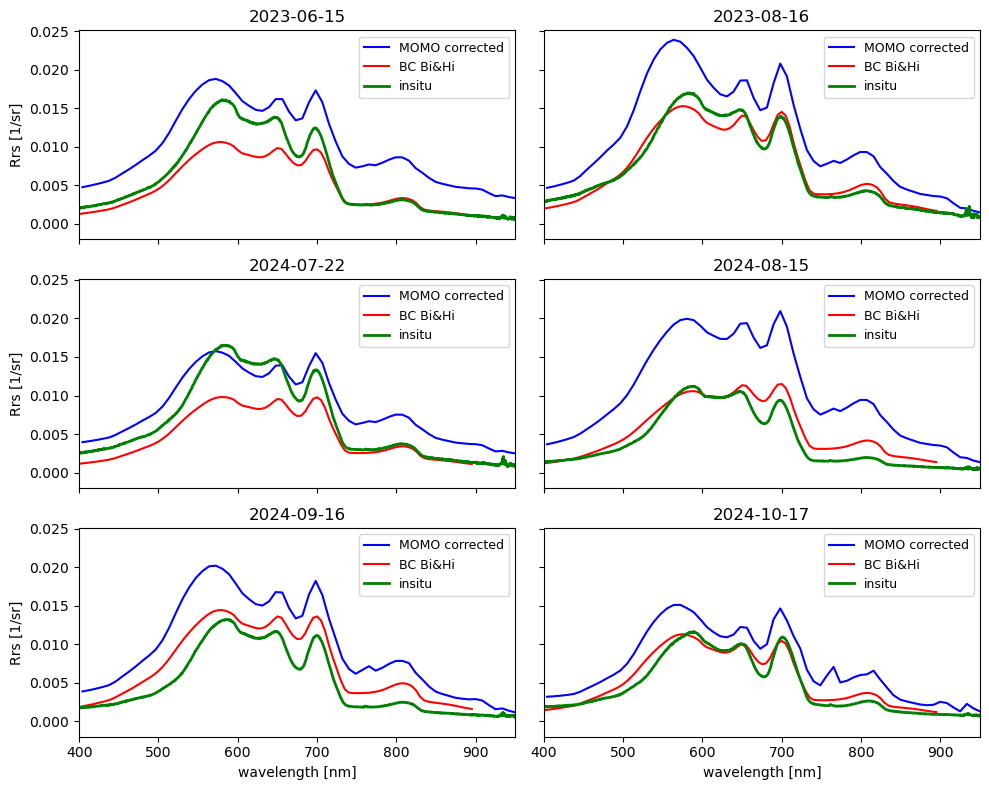

In [9]:
Nx, Ny = (2,3)
fig, ax=plt.subplots(nrows=3, ncols=2, figsize=(10,8), sharex=True, sharey=True)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl, Rrs_glint_sel.iloc[iy*Nx+ix,:].values, 'b-', label='MOMO corrected')
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO no glint')
        
        ax[iy, ix].plot(wl_fw, forward_sel.iloc[iy*Nx+ix,:].values, 'r-', label='BC Bi&Hi')
        ax[iy, ix].plot(wl_ins, insituRrs_sel.iloc[iy*Nx+ix,:].values, 'g-', linewidth=2, label='insitu')
        ax[iy, ix].set_title(str(ID[iy*Nx+ix]).split('T')[0])
        ax[iy, ix].legend(fontsize=9)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

## Vörtsjärv Inversion - based on MOMO  
Use only inversions with the correctly set anap_spec and S_Nap.  
Fit for spectrum 0 -> NAP0  
Fit for spectrum 1 -> NAP1  
etc.

In [281]:
outpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\"
fnames = os.listdir(outpath)
locName = 'vortsjarv'
version_inv = 'Inv0.6b' # 'Inv0.5d'
fnames = [a for a in fnames if locName in a and version_inv in a]
fnames

['inverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarv_allOWTs_Inv0.6b_NAP0.txt',
 'inverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarv_allOWTs_Inv0.6b_NAP1.txt',
 'inverted_Sim_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarv_allOWTs_Inv0.6b_NAP0.txt',
 'inverted_Sim_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarv_allOWTs_Inv0.6b_NAP1.txt']

In [282]:
iopfnames = [fn for fn in fnames if 'IOP' in fn]
simfnames = [fn for fn in fnames if 'Sim' in fn]

iop_inv = None
sim_inv = None
for simfn, iopfn in zip(simfnames, iopfnames):
    d = pd.read_csv(outpath + simfn, header=0)
    d2 = pd.read_csv(outpath + iopfn, header=0)
    iN = int(iopfn.split('NAP')[1].split('.')[0])
    
    if iop_inv is None:
        iop_inv = d2.iloc[iN,:]
    else:
        inter = d2.iloc[iN,:]
        iop_inv = pd.concat([iop_inv, inter], axis=1, ignore_index=True)

    if sim_inv is None:
        sim_inv = d.iloc[iN,:]
    else:
        inter = d.iloc[iN,:]
        sim_inv = pd.concat([sim_inv, inter], axis=1, ignore_index=True)

iop_inv_ = pd.DataFrame(np.transpose(iop_inv.values), columns=iop_inv.index)
sim_inv_ = pd.DataFrame(np.transpose(sim_inv.values), columns=sim_inv.index)

iop_inv_['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_inv_['date'].values])
iop_inv_ = iop_inv_.set_index('date')

sim_inv_['date'] = pd.to_datetime([str(a).split('+')[0] for a in sim_inv_['date'].values])
sim_inv_ = sim_inv_.set_index('date')

outVar = ['C_0', 'C_1', 'C_2', 'C_3', 'C_5', 'C_6', 'C_Y', 'C_ism', 'C_phy']
# for v in outVar:
#     iop_inv_[v] = np.round(iop_inv_[v].values, 3)
iop_inv_[outVar]

,C_0,C_1,C_2,C_3,C_5,C_6,C_Y,C_ism,C_phy
date,,,,,,,,,
2023-05-15 12:00:00,0.0,0.0,6.005754,14.5489,0.0,32.7815,2.143258,0.243816,53.336154
2023-06-15 12:00:00,0.0,0.0,7.125757,39.484782,0.0,45.182604,0.990334,4.381269,91.793144


In [257]:
sim_inv_

,Unnamed: 0,400.0,405.0,410.0,415.0,420.0,425.0,430.0,435.0,440.0,...,855.0,860.0,865.0,870.0,875.0,880.0,885.0,890.0,895.0,date
0,0,0.002397,0.00257,0.002749,0.002938,0.003142,0.003357,0.00358,0.003814,0.004079,...,0.003273,0.003175,0.003066,0.002944,0.0028,0.002644,0.002496,0.002361,0.002242,2023-05-15 12:00:00
1,1,0.00483,0.005098,0.005349,0.005606,0.005887,0.00618,0.006468,0.006771,0.007167,...,0.006412,0.006216,0.006001,0.005758,0.005471,0.005161,0.004866,0.004596,0.004359,2023-06-15 12:00:00
2,2,0.008222,0.008482,0.008697,0.008924,0.009197,0.009491,0.009774,0.010082,0.010561,...,0.009858,0.009553,0.009217,0.00884,0.008393,0.007912,0.007452,0.007033,0.006664,2023-08-16 12:00:00
3,3,0.008706,0.008952,0.009152,0.009371,0.009644,0.009943,0.010233,0.010554,0.011059,...,0.014545,0.014103,0.013614,0.013064,0.012412,0.011706,0.011031,0.010413,0.009867,2023-09-14 12:00:00
4,4,0.002665,0.002867,0.003077,0.003301,0.003541,0.003795,0.004058,0.004334,0.004638,...,0.006107,0.005916,0.005706,0.005471,0.005193,0.004895,0.00461,0.004352,0.004124,2024-04-11 12:00:00
5,5,0.003934,0.004141,0.004331,0.004527,0.004745,0.004974,0.005197,0.005433,0.005756,...,0.00692,0.006706,0.006471,0.006207,0.005895,0.005559,0.005239,0.004947,0.00469,2024-06-13 12:00:00
6,6,0.004515,0.004713,0.004892,0.005079,0.005289,0.005511,0.005729,0.005961,0.006282,...,0.006349,0.006153,0.005937,0.005695,0.005408,0.0051,0.004806,0.004538,0.004303,2024-07-22 12:00:00
7,7,0.004723,0.00503,0.005334,0.005649,0.005986,0.006338,0.006694,0.007065,0.00751,...,0.00849,0.008234,0.007951,0.007631,0.007252,0.006841,0.006449,0.006091,0.005776,2024-08-15 12:00:00
8,8,0.007726,0.008114,0.00847,0.008834,0.009232,0.009646,0.010051,0.010475,0.01104,...,0.010022,0.00972,0.009385,0.009008,0.00856,0.008076,0.007613,0.007189,0.006816,2024-09-16 12:00:00
9,9,0.005484,0.005716,0.00592,0.00613,0.006369,0.006621,0.006863,0.00712,0.007492,...,0.007138,0.006919,0.006677,0.006406,0.006085,0.005739,0.005409,0.005108,0.004843,2024-10-17 12:00:00


In [278]:
ID = np.intersect1d(insituRrs.index, Rrs_glint.index)

# ID = np.array('2023-06-15 12:00:00', '2023-08-16 12:00:00', '2024-07-22 12:00:00', '2024-08-15 12:00:00', '2024-09-16 12:00:00', '2024-10-17 12:00:00')

sim_inv_sel = sim_inv_.loc[ID,:]
wl_sim = np.asarray([float(a) for a in sim_inv_sel.columns.values[1:]])

iop_inv_sel = iop_inv_.loc[ID,:]

In [280]:
iop_inv_sel[outVar]

,C_0,C_1,C_2,C_3,C_5,C_6,C_Y,C_ism,C_phy
date,,,,,,,,,
2023-06-15 12:00:00,0.0,0.0,7.125757,39.484782,0.0,45.182604,0.990334,4.381269,91.793144
2023-08-16 12:00:00,0.0,0.0,4.029723,50.293493,0.0,50.995807,0.166335,6.487941,105.319023
2024-07-22 12:00:00,0.0,0.0,10.677449,44.620531,0.0,49.35134,1.24693,2.135986,104.649319
2024-08-15 12:00:00,0.0,0.0,8.544373,36.731745,0.0,59.42268,1.616557,9.541637,104.698797
2024-09-16 12:00:00,0.0,0.0,3.604724,41.962828,0.0,49.724601,0.53564,5.322991,95.292153
2024-10-17 12:00:00,0.0,0.0,8.705506,48.581389,0.0,48.645738,0.748983,2.672466,105.932633


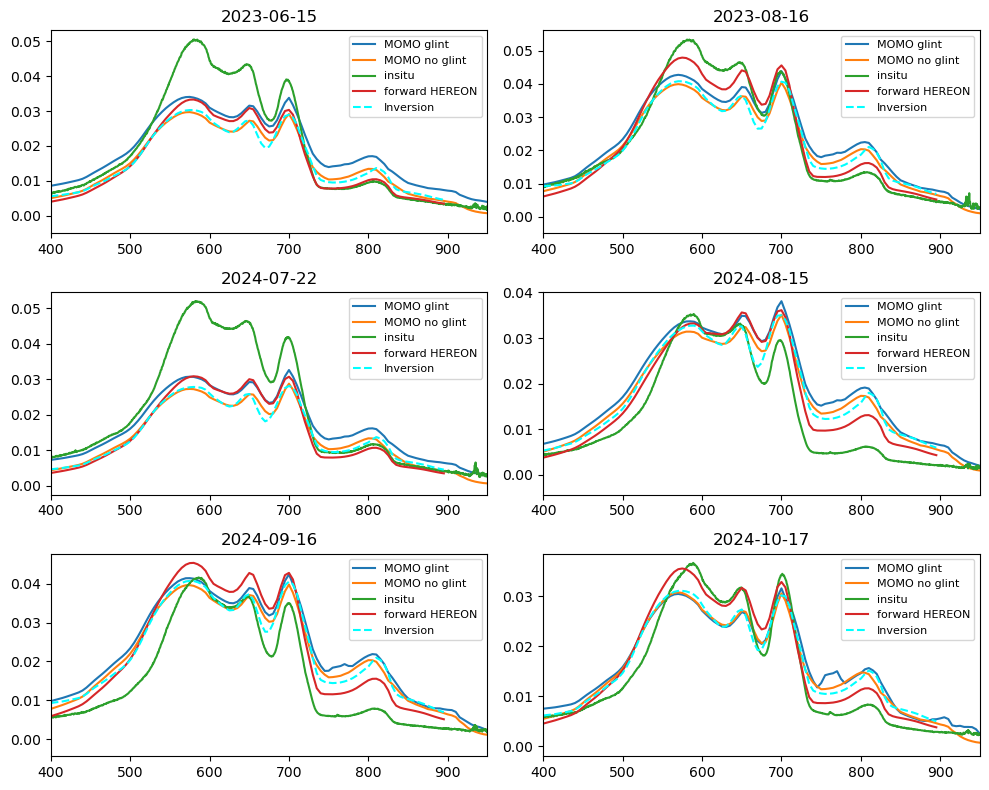

In [277]:
Nx, Ny = (2,3)
fig, ax=plt.subplots(nrows=3, ncols=2, figsize=(10,8))

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl, Rrs_glint_sel.iloc[iy*Nx+ix,:].values, 'b-', label='MOMO glint')
        ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO no glint')
        ax[iy, ix].plot(wl_fw, forward_sel.iloc[iy*Nx+ix,:].values, 'r-', label='forward HEREON')
        # ax[iy, ix].plot(wl_sim, np.pi*sim_inv_sel.iloc[iy*Nx+ix,1:].values, '--', color='aqua', label='Inversion')
        ax[iy, ix].plot(wl_ins, insituRrs_sel.iloc[iy*Nx+ix,:].values, 'g-', linewidth=2, label='insitu')
        ax[iy, ix].set_title(str(ID[iy*Nx+ix]).split('T')[0])
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))


fig.tight_layout()
plt.show()

## Inversion - based on in-situ

In [98]:
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\"
versionInv = 'Inv0.6_' # 'Inv0.6'
fnames = os.listdir(path)
fnames = [fn for fn in fnames if 'vortsjarvInsitu' in fn and versionInv in fn ] #and versionInv in fn
print(fnames)
iop_inv = pd.read_csv(path + fnames[0], header=0)
iop_inv['date'] = pd.to_datetime(iop_inv['date'])
iop_inv = iop_inv.set_index('date')
Rrs_inv = pd.read_csv(path + fnames[1], header=0)
Rrs_inv['date'] = pd.to_datetime(Rrs_inv['date'])
Rrs_inv = Rrs_inv.set_index('date')
Rrs_inv = Rrs_inv.iloc[:, 1:]
wavelengths = np.asarray([float(a) for a in Rrs_inv.columns.values])

['inverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarvInsitu_allOWTs_Inv0.6_NAPdefault.txt', 'inverted_Sim_bio_optics_HEREONfull_CHIME_sim_AQUATIME_vortsjarvInsitu_allOWTs_Inv0.6_NAPdefault.txt']


In [56]:
## original Insitu spectra, converted to Rrs ##
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\Case_Study_3\Vortsjarv\Hyperspectral data\\"
fname = ['Insitu_Vorstjarv_Rrs_Hypstar_radiometric_23-24.csv']
dat = pd.read_csv(path+ fname[0], header=0)
dat['date'] = pd.to_datetime(dat['date'])
dat = dat.set_index('date')
wlstr = [str(wl) for wl in wavelengths]
dat = dat[wlstr]
dat

,400.014032063158,400.485041301256,400.956112142424,401.427244542035,401.898438455383,402.369693837676,402.841010644038,403.312388829511,403.783828349053,404.255329157537,...,895.382034158634,895.878231907142,896.374403702715,896.870549416346,897.366668918941,897.862762081322,898.35882877423,898.854868868321,899.350882234167,899.846868742257
date,,,,,,,,,,,,,,,,,,,,,
2023-05-07 12:00:00,0.001218,0.001228,0.001189,0.001207,0.001191,0.001223,0.001216,0.001229,0.001220,0.001207,...,0.000349,0.000361,0.000347,0.000339,0.000349,0.000360,0.000340,0.000348,0.000347,0.000337
2023-05-08 12:00:00,0.001079,0.001109,0.001110,0.001088,0.001094,0.001096,0.001084,0.001059,0.001115,0.001098,...,0.000322,0.000303,0.000324,0.000317,0.000329,0.000296,0.000316,0.000314,0.000317,0.000301
2023-05-10 12:00:00,0.000872,0.000886,0.000871,0.000900,0.000858,0.000883,0.000874,0.000875,0.000903,0.000893,...,0.000228,0.000218,0.000218,0.000217,0.000206,0.000208,0.000201,0.000207,0.000210,0.000231
2023-05-11 12:00:00,0.000919,0.000921,0.000923,0.000925,0.000913,0.000940,0.000910,0.000931,0.000911,0.000947,...,0.000226,0.000239,0.000238,0.000224,0.000223,0.000239,0.000225,0.000222,0.000232,0.000239
2023-05-12 12:00:00,0.000979,0.000969,0.000977,0.000990,0.000986,0.000980,0.000974,0.000977,0.000982,0.000996,...,0.000241,0.000231,0.000229,0.000227,0.000213,0.000230,0.000212,0.000230,0.000206,0.000229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-19 12:00:00,0.002036,0.002054,0.002068,0.002026,0.001999,0.002050,0.002028,0.002018,0.002065,0.002033,...,0.001043,0.001014,0.000985,0.001024,0.000982,0.001004,0.000985,0.000990,0.000988,0.000987
2024-10-20 12:00:00,0.001962,0.001995,0.001978,0.001956,0.001991,0.001990,0.002009,0.001985,0.002025,0.001986,...,0.001052,0.001032,0.001052,0.001022,0.001065,0.001026,0.001034,0.001027,0.001054,0.000990
2024-10-29 12:00:00,0.002876,0.002930,0.002943,0.002894,0.002924,0.002917,0.002926,0.002984,0.002921,0.002963,...,0.001227,0.001211,0.001188,0.001214,0.001163,0.001249,0.001165,0.001216,0.001148,0.001230


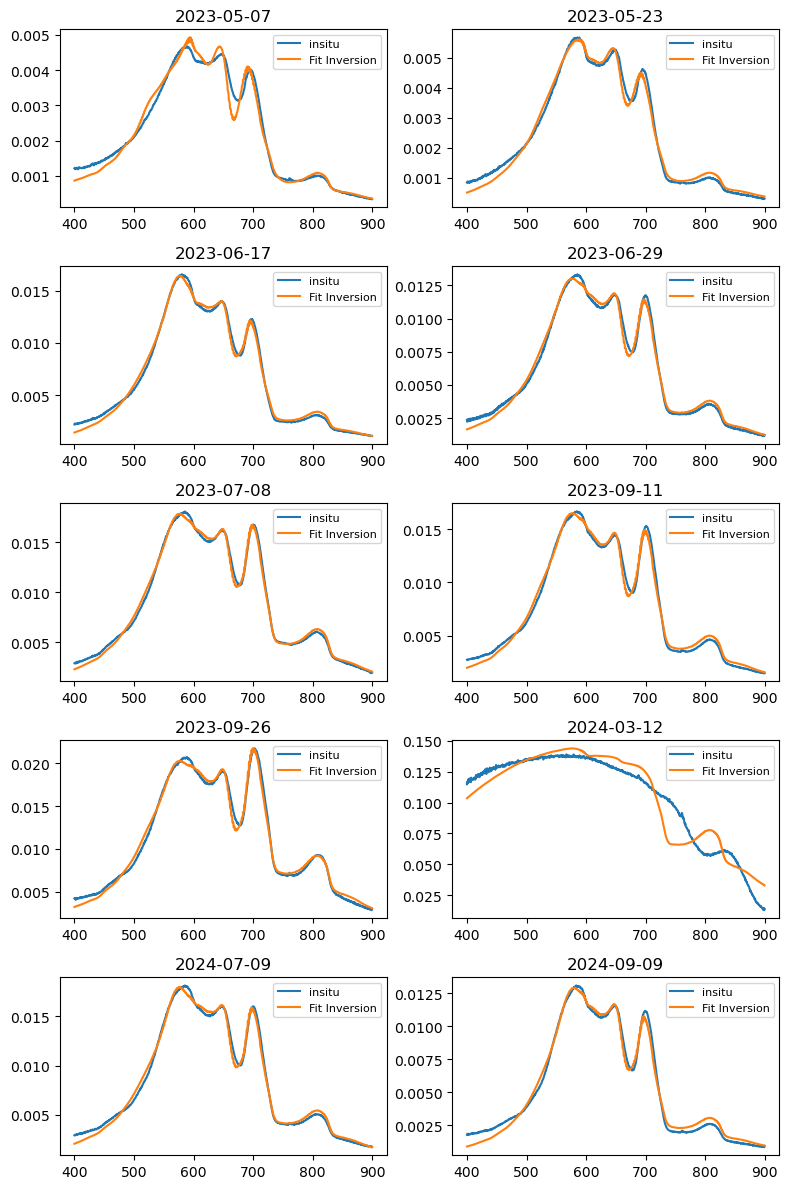

In [101]:
Nx, Ny = (2, 5)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(8,12))

IDList = np.random.choice(dat.index, Nx*Ny, replace=False)
IDList = np.sort(IDList)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wavelengths, dat.loc[IDList[iy*Nx + ix], :], '-', label='insitu')
        ax[iy, ix].plot(wavelengths, Rrs_inv.loc[IDList[iy*Nx + ix], :], '-', label='Fit Inversion')
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_title(str(IDList[iy*Nx + ix]).split('T')[0])

fig.tight_layout()
plt.show()

In [75]:
iop_insitu.columns.values

array(['datetime', 'Temp °C', 'Salinity [PSU]', 'Chlg [µg/l]',
       'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]',
       'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'ag(440) [1/m]',
       'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]',
       'anap_spec(440) [m2 g-1]', 'Snap [1/nm]', 'latitude_station',
       'longitude_station', 'latitude_cams', 'longitude_cams', 'u10',
       'v10', 'bcaod550', 'duaod550', 'omaod550', 'ssaod550', 'aod469',
       'aod550', 'aod670', 'aod865', 'aod1240', 'tc_ch4', 'gtco3', 'tcwv'],
      dtype=object)

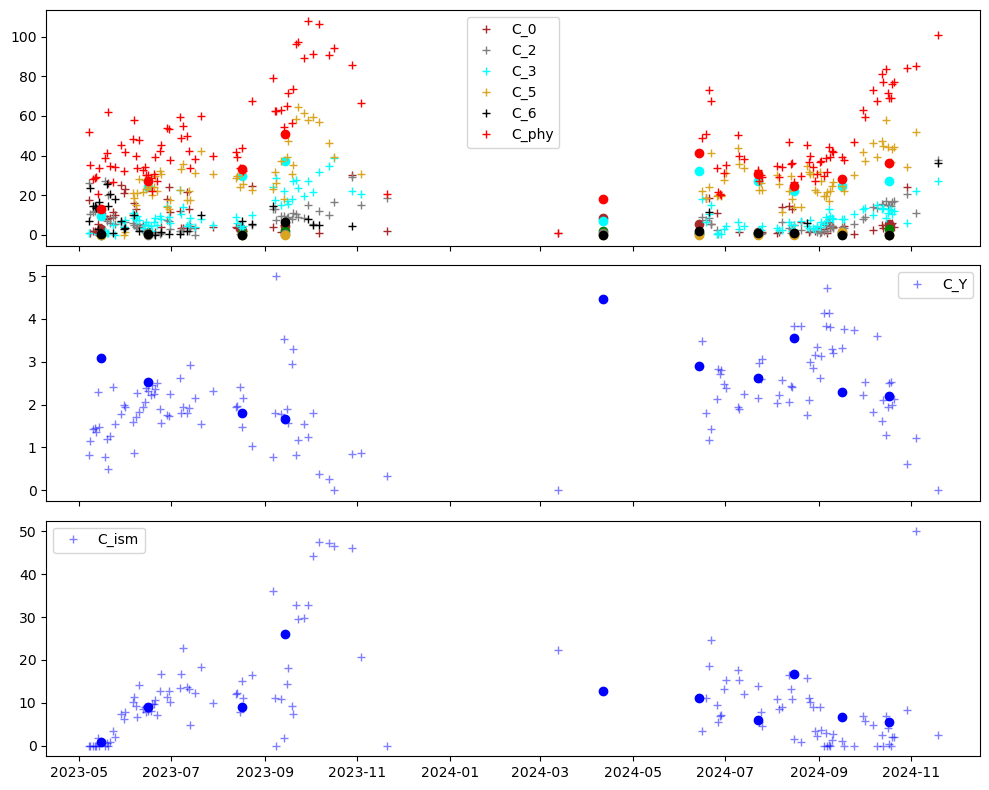

In [99]:
## vortsjarvInsitu_Inv0.6 (6 groups),  vortsjarvInsitu_Inv0.7 (2 groups), vortsjarvInsitu_Inv0.7b (other 2 groups)
varList = ['C_0', 'C_1', 'C_2', 'C_3', 'C_5', 'C_6', 'C_phy', 'C_Y', 'C_ism']
colList = ['brown', 'green', 'grey', 'cyan', 'goldenrod', 'black', 'red']
varInsList = ['Ckie [µg/l]', 'Cgr [µg/l]', 'Ccry [µg/l]', 'Cbl [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'Chlg [µg/l]']

fig, ax = plt.subplots(nrows=3, figsize=(10,8), sharex=True)
for v, vi, col in zip(varList[:-2], varInsList, colList):
    ID = iop_inv[v]> 0.01
    if np.sum(ID)>0:
        ax[0].plot(iop_inv[v].loc[ID], '+', color=col, label=v)
    ax[0].plot(iop_insitu[vi], 'o', color=col)
ax[0].legend()
ax[1].plot(iop_inv['C_Y'], 'b+', alpha=0.5, label='C_Y')
ax[1].plot(iop_insitu['ag(440) [1/m]'], 'bo')
ax[1].legend()
ax[2].plot(iop_inv['C_ism'], 'b+', alpha=0.5, label='C_ism')
ax[2].plot(iop_insitu['NAP [mg/l]'], 'bo')
ax[2].legend()
fig.tight_layout()
plt.show()

## web version Bi model

In [10]:
fpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\concistency\\" 
fnamesList = os.listdir(fpath)
fnamesList = [fn for fn in fnamesList if 'vortsjarv' in fn]

ID = np.array(('2023-06-15T12:00:00', '2023-08-16T12:00:00', '2024-07-22T12:00:00', '2024-08-15T12:00:00', '2024-09-16T12:00:00', '2024-10-17T12:00:00'))

print(fnamesList)
biDict = {}
for id_ in ID:
    key = str(id_).split('T')[0]
    fname = [fn for fn in fnamesList if key.replace('-', '') in fn]
    bi = pd.read_csv(fpath+fname[0], header=0)
    biDict[key] = bi


['IOP_spectra_outputs_webHEREON_vortsjarv_20230615.csv', 'IOP_spectra_outputs_webHEREON_vortsjarv_20230816.csv', 'IOP_spectra_outputs_webHEREON_vortsjarv_20240722.csv', 'IOP_spectra_outputs_webHEREON_vortsjarv_20240815.csv', 'IOP_spectra_outputs_webHEREON_vortsjarv_20240916.csv', 'IOP_spectra_outputs_webHEREON_vortsjarv_20241017.csv']


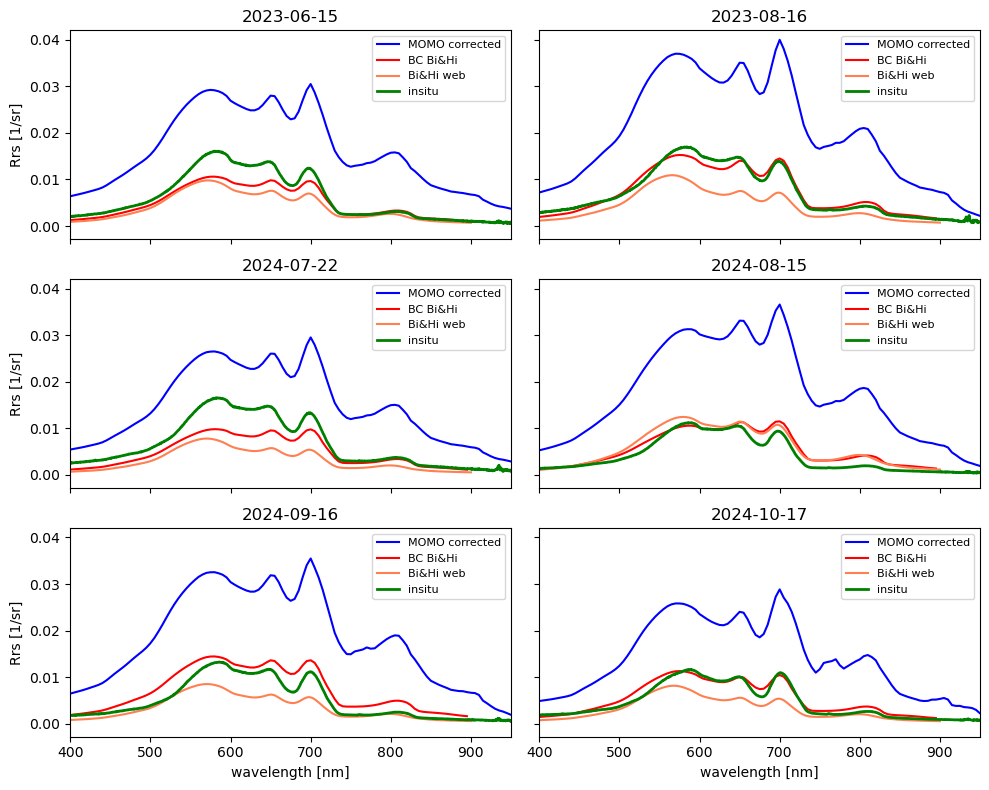

In [11]:
Nx, Ny = (2,3)
fig, ax=plt.subplots(nrows=3, ncols=2, figsize=(10,8), sharex=True, sharey=True)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl, Rrs_glint_sel.iloc[iy*Nx+ix,:].values, 'b-', label='MOMO corrected')
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO no glint')
        
        ax[iy, ix].plot(wl_fw, forward_sel.iloc[iy*Nx+ix,:].values, 'r-', label='BC Bi&Hi') #'forward HEREON'
        d = biDict[str(ID[iy*Nx+ix]).split('T')[0]]
        ax[iy, ix].plot(d['wavelen'].values, d['Rrs_L11'].values, '-', color='coral', label='Bi&Hi web') #webHEREON
        # ax[iy, ix].plot(wl_sim, np.pi*sim_inv_sel.iloc[iy*Nx+ix,1:].values, '--', color='aqua', label='Inversion')
        ax[iy, ix].plot(wl_ins, insituRrs_sel.iloc[iy*Nx+ix,:].values, 'g-', linewidth=2, label='insitu')
        ax[iy, ix].set_title(str(ID[iy*Nx+ix]).split('T')[0])
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

In [49]:
## default value anap_spec at 440nm
a_md_spec = absorption.a_md_spec(440)
a_md_spec

0.05437963977516812

## Geometry - Sun zenith angle

In [11]:
from suncalc import get_position, get_times
from datetime import datetime

In [12]:
G_df, solz, senz, phi = lee.read_G_LUT()

In [13]:
xG0w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0w')
xG1w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1w')
xG0p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0p')
xG1p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1p')

In [14]:
# Vörtsjärv:  lat: 58.2111  lon: 26.10556
sun_dict = get_position(insitu.datetime, lng= 26.10556, lat=58.2111)
sun_dict['zenith'] = (np.pi/2. - sun_dict['altitude'])*180./np.pi
sun_dict

{'azimuth': array([0.39751121, 0.38448873, 0.38483972, 0.399699  , 0.42833177,
        0.46839597, 0.49160926, 0.51620366, 0.54518078, 0.59160731,
        0.61481896, 0.63577885, 0.65373774, 0.66802257, 0.68360315,
        0.68446254, 0.68087791, 0.67336497, 0.66271445, 0.64991064,
        0.63601428, 0.62203416, 0.60881615, 0.59697094, 0.58684774,
        0.57854811, 0.57196584, 0.56683851, 0.56279926, 0.55942248,
        0.55626099, 0.55287528, 0.54885638, 0.5438446 , 0.53754599,
        0.52974756, 0.50929067, 0.48289935, 0.45293661, 0.42345948,
        0.39938221, 0.3843587 , 0.3979222 , 0.42539625, 0.46457137,
        0.51544228, 0.53712819, 0.56255966, 0.58742936, 0.61096694,
        0.63239183, 0.65094628, 0.66775564, 0.67680293, 0.68315102,
        0.68484322, 0.68203078, 0.67517479, 0.66502105, 0.65252682,
        0.63874852, 0.62471334, 0.61130316, 0.59917435, 0.5887233 ,
        0.58009389, 0.57321381, 0.56784492, 0.56363568, 0.56016813,
        0.55699666, 0.55367858, 0.549

In [15]:
G = np.zeros((insitu.shape[0], 4))
senz, phi = (0., 0.) # (50., 135.) # (30., 135.) # (0,0)
G[:, 0] = xG0w.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 1] = xG1w.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 2] = xG0p.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 3] = xG1p.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()

In [16]:
insitu['G0w'] = G[:, 0]
insitu['G1w'] = G[:, 1]
insitu['G0p'] = G[:, 2]
insitu['G1p'] = G[:, 3]
insitu['SZA'] = sun_dict['zenith']
insitu['OZA'] = senz
insitu['dAA'] = phi

# inputPath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\"
# metaDict = {'helsinki_ss': {'folder': 'Helsinki\\input_simulations' , 'fileName':  'helsinki_silja_serenade_IOP_v0.1b.csv'}, # helsinki_silja_serenade_daily_v0.3.cvs
#          'helsinki_fm': {'folder': 'Helsinki\\input_simulations', 'fileName': 'helsinki_finnmaid_daily_v0.3.csv'}, 
#         'berlin_muggelsee': {'folder': 'Muggelsee - Berlin\\input_simulations' , 'fileName': 'berlin_muggelsee_IOP_daily_v0.3.csv'}, 
#        }
print(position)
folder = metaDict[position]['folder']
fname = metaDict[position]['fileName']
outpath = inputPath + folder+ "\\" + fname.split('.csv')[0]+ "_OZA2.csv"
print(outpath)
# insitu.to_csv(outpath, header=True, index=False)

berlin_mueggelsee
Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\berlin_muggelsee_IOP_v0.3_OZA2.csv


# Belgian Coast - insitu spectra
No concentration data available.  
Run inversion on data with Brown, Phaeocystis, Dinoflagellates + CDOM + NAP  
**Spectra are water leaving reflectance! -> Rrs is need for inversion.**

## Read data

### Insitu spectra - rhow

In [10]:
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\concistency\\"
fname = "belgian_coast_all.csv" 
d = pd.read_csv(path + fname, header=0)
d = d.iloc[:, 1:]
d['date'] = pd.to_datetime(d['datetime_utc'])
d = d.set_index('date')
d.drop(columns=['datetime_utc'], inplace=True)
wlStr = np.asarray([a for a in d.columns.values if a.startswith('wl')])
wl = np.asarray([float(a.split('_')[1]) for a in wlStr])

locName = 'BelgianCoastCPOWER' # 'BelgianCoastRT1' # BelgianCoastCPOWER'
ID = d.name == locName.split('Coast')[1]
d = d.loc[ID,:]
d

,name,wl_355.0,wl_357.5,wl_360.0,wl_362.5,wl_365.0,wl_367.5,wl_370.0,wl_372.5,wl_375.0,...,wl_922.5,wl_925.0,wl_927.5,wl_930.0,wl_932.5,wl_935.0,wl_937.5,wl_940.0,wl_942.5,wl_945.0
date,,,,,,,,,,,,,,,,,,,,,
2025-01-09 12:02:05+00:00,CPOWER,0.018433,0.018757,0.019065,0.019344,0.019644,0.020055,0.020352,0.020830,0.021219,...,0.002533,0.002538,0.002510,0.002520,0.002712,0.002754,0.002659,0.002797,0.002812,0.002715
2025-01-10 11:04:16+00:00,CPOWER,0.009172,0.009535,0.009914,0.010263,0.010639,0.011075,0.011453,0.012017,0.012514,...,0.001655,0.001664,0.001636,0.001666,0.001760,0.001812,0.001800,0.001787,0.001701,0.001708
2025-01-11 12:01:53+00:00,CPOWER,0.013783,0.013989,0.014194,0.014336,0.014515,0.014779,0.014950,0.015263,0.015495,...,0.001073,0.001086,0.001110,0.001197,0.001295,0.001298,0.001240,0.001308,0.001464,0.001334
2025-01-13 11:05:22+00:00,CPOWER,0.013074,0.013494,0.013942,0.014356,0.014792,0.015309,0.015746,0.016424,0.017031,...,0.002854,0.002851,0.002858,0.002789,0.003150,0.003318,0.003178,0.003175,0.002992,0.002945
2025-01-27 11:05:42+00:00,CPOWER,0.016202,0.016601,0.017009,0.017376,0.017764,0.018258,0.018665,0.019280,0.019804,...,0.008743,0.008792,0.008907,0.008872,0.009363,0.009302,0.008757,0.008946,0.008769,0.008839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-24 09:44:27+00:00,CPOWER,0.008513,0.008643,0.008760,0.008928,0.009072,0.009180,0.009410,0.009514,0.009714,...,0.002776,0.002791,0.002797,0.002817,0.002948,0.002915,0.002846,0.002798,0.002806,0.002789
2024-10-25 10:22:55+00:00,CPOWER,0.012262,0.012310,0.012330,0.012437,0.012503,0.012518,0.012693,0.012682,0.012789,...,0.002263,0.002293,0.002336,0.002388,0.002574,0.002620,0.002668,0.002789,0.002597,0.002606
2024-10-27 09:05:18+00:00,CPOWER,0.006148,0.006278,0.006387,0.006544,0.006682,0.006791,0.006991,0.007105,0.007294,...,0.001933,0.001939,0.001942,0.001996,0.002149,0.002166,0.002106,0.001983,0.002056,0.002123


### Add Geometry dependent parameters G0w, G1w, G0p, G1p

### Inversion spectra - Rrs & conc.

In [137]:
path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\"

fnames = [fn for fn in os.listdir(path) if locName in fn]

iop_inv = pd.read_csv(path + fnames[0], header=0)
iop_inv['date'] = pd.to_datetime(iop_inv['date'])
iop_inv = iop_inv.set_index('date')
Rrs_inv = pd.read_csv(path + fnames[1], header=0)
Rrs_inv['date'] = pd.to_datetime(Rrs_inv['date'])
Rrs_inv = Rrs_inv.set_index('date')
Rrs_inv = Rrs_inv.iloc[:, 1:]
wavelengths = np.asarray([float(a) for a in Rrs_inv.columns.values])

## Analyse

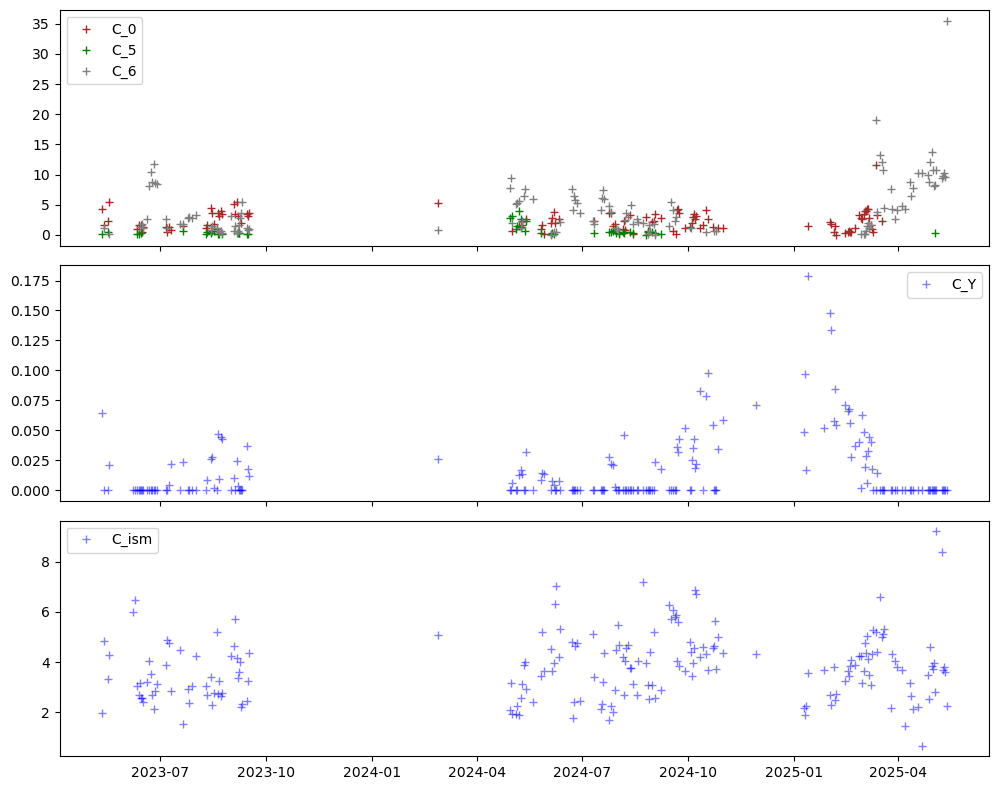

In [138]:
## Belgian Coast: 3 groups Brown/Diatoms, Phaeocystis, Dinoflagellates
varList = ['C_0', 'C_5', 'C_6', 'C_phy', 'C_Y', 'C_ism']
colList = ['brown', 'green', 'grey']
# varInsList = ['Ckie [µg/l]', 'Cgr [µg/l]', 'Ccry [µg/l]', 'Cbl [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'Chlg [µg/l]']

fig, ax = plt.subplots(nrows=3, figsize=(10,8), sharex=True)
for v, col in zip(varList[:-2], colList):
    ID = iop_inv[v]> 0.01
    if np.sum(ID)>0:
        ax[0].plot(iop_inv[v].loc[ID], '+', color=col, label=v)

ax[0].legend()
ax[1].plot(iop_inv['C_Y'], 'b+', alpha=0.5, label='C_Y')
# ax[1].plot(iop_insitu['ag(440) [1/m]'], 'bo')
ax[1].legend()
ax[2].plot(iop_inv['C_ism'], 'b+', alpha=0.5, label='C_ism')
# ax[2].plot(iop_insitu['NAP [mg/l]'], 'bo')
ax[2].legend()
fig.tight_layout()
plt.show()

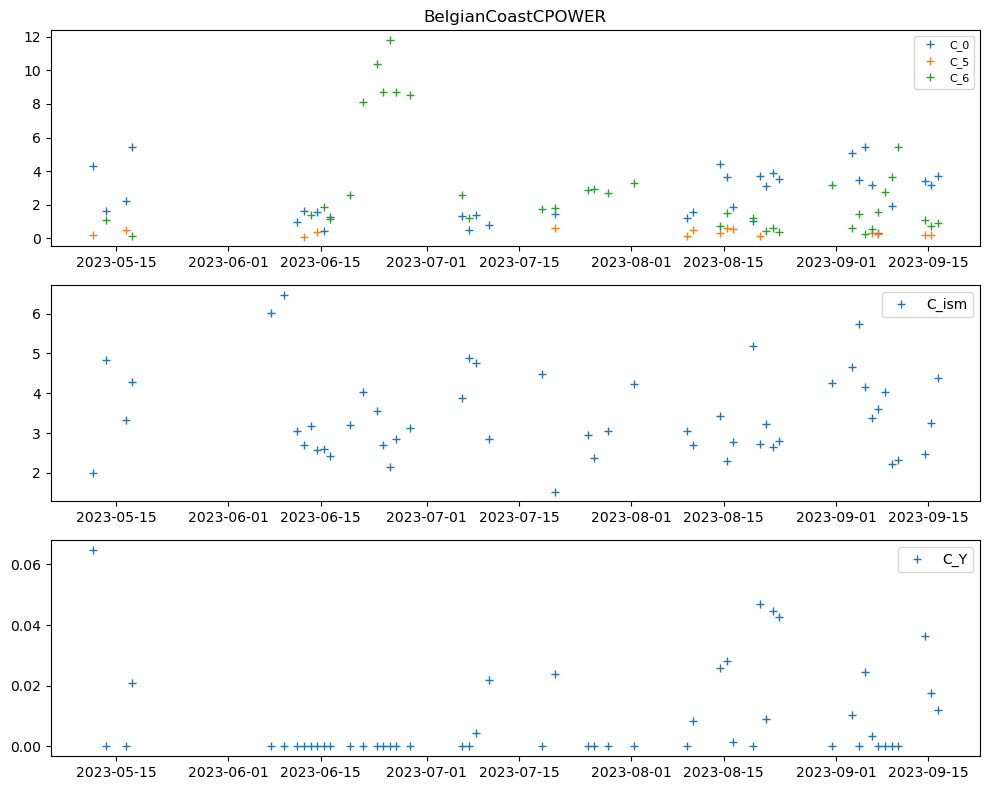

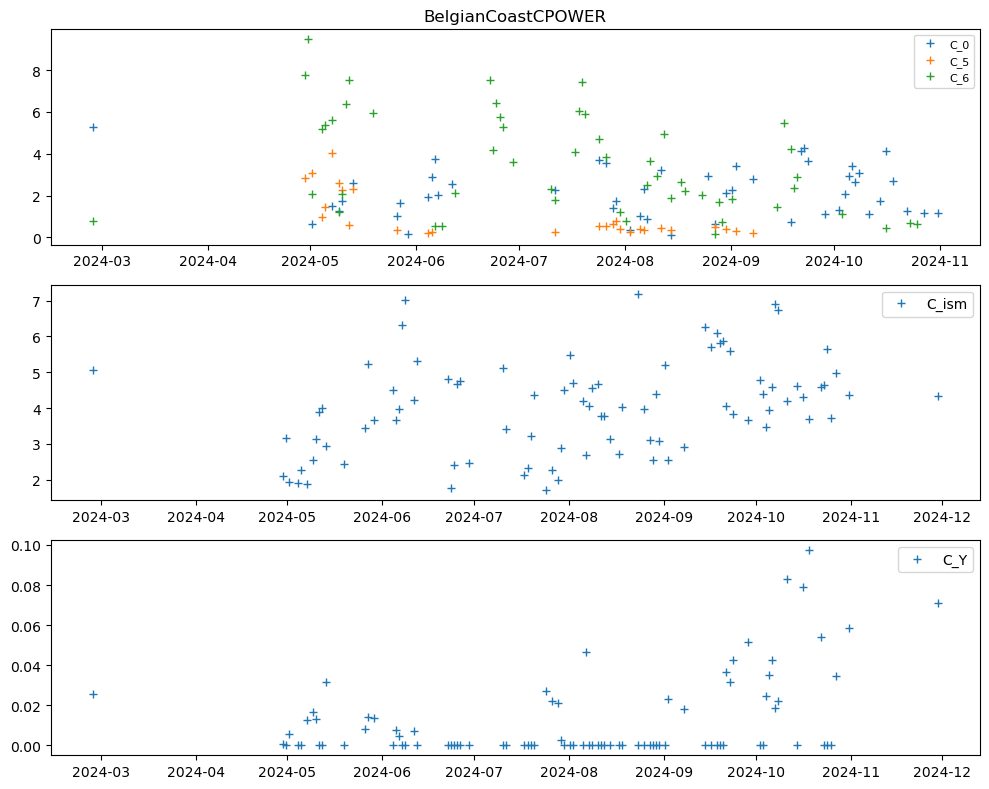

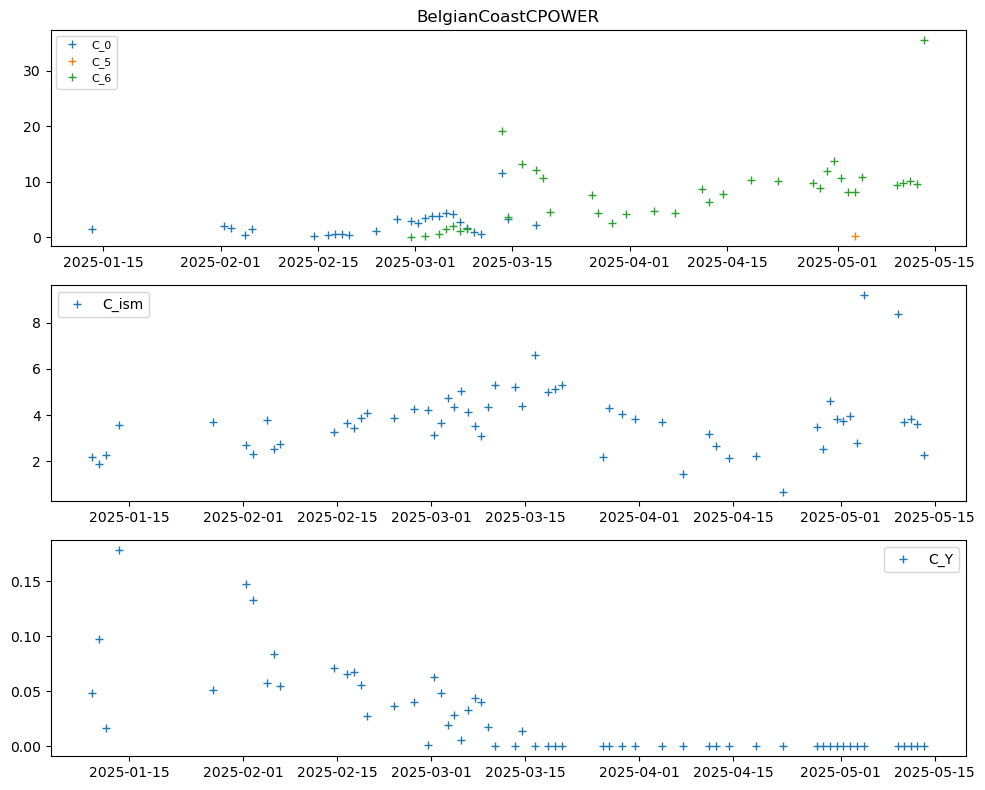

In [139]:
yearArr = np.asarray([a.year for a in iop_inv.index])
yearList = np.unique(yearArr)

for year in yearList[:]:

    fig, ax=plt.subplots(nrows=3, figsize=(10, 8))
    for i in range(8):
        ID = np.logical_and(iop_inv['C_'+str(i)].values>0.1, yearArr== year)
        if np.sum(ID)>0:
            ax[0].plot(iop_inv['C_'+str(i)].loc[ID], '+', label='C_'+str(i))
    
    # insituGroups = ['Ckie [µg/l]', 'Cgr [µg/l]', 'Cbl [µg/l]', 'Ccry [µg/l]']  # elbe v0.1: no'Cdino [µg/l]'
    
    # for ig in insituGroups:
    #     if type(ig) == list:
    #         y = np.nansum(insitu[ig].values, axis=1)
    #     else:
    #         y = insitu[ig].values
        
    #     ID = np.logical_and(y>0.1, yearArr==year)
    #     if np.sum(ID)>0:
    #         ax[0].plot(insitu.index[ID], y[ID], 'o', label=ig, alpha=0.3)
    
    ax[0].legend(fontsize=8)
    # ax[0].set_ylim((0., 12))
    ax[0].set_title(locName)

    IDy = yearArr== year
    ax[1].plot(iop_inv['C_ism'].loc[IDy], '+', label='C_ism')
    # ax[1].plot(insitu['NAP [mg/l]'].loc[IDy], 'o', alpha=0.4, label='NAP insitu')
    ax[1].legend()
    # ax[1].set_ylim((0,2.2))
    
    ax[2].plot(iop_inv['C_Y'].loc[IDy], '+', label='C_Y')
    # ax[2].plot(insitu['ag(440) [1/m]'].loc[IDy], 'o', alpha=0.4, label='ag(440) [1/m] insitu')
    ax[2].legend()
    # ax[1].set_ylim((0,2.2))
    
    fig.tight_layout()
    plt.show()

## Analyse

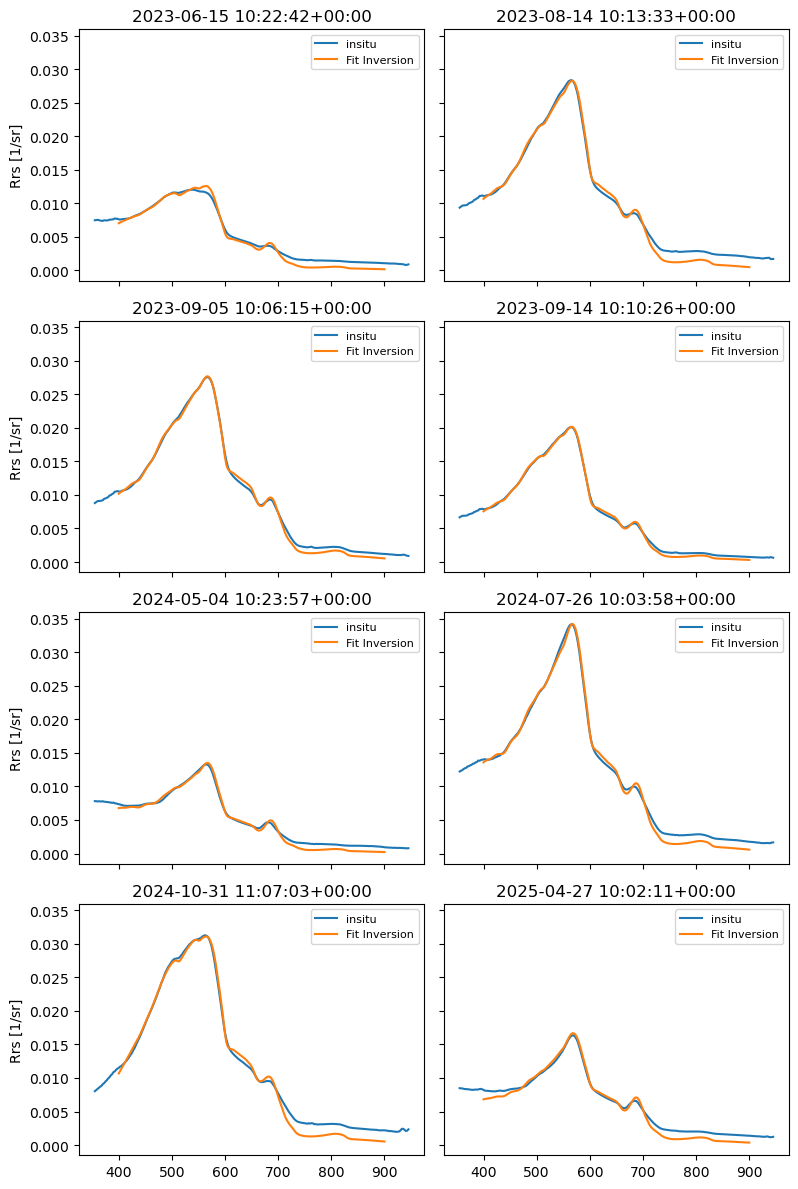

In [140]:
Nx, Ny = (2, 4)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(8,12), sharex=True, sharey=True)

IDList2 = np.random.choice(d.index, Nx*Ny, replace=False)
IDList2 = np.sort(IDList2)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl, d.loc[IDList2[iy*Nx + ix]].values[1:] , '-', label='insitu')
        ax[iy, ix].plot(wavelengths, Rrs_inv.loc[IDList2[iy*Nx + ix], :], '-', label='Fit Inversion')
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_title(str(IDList2[iy*Nx + ix]).split('T')[0])
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')
fig.tight_layout()
plt.show()

# Analyse Systematic difference: MOMO & Forward BC Bi&Hi  
Simulations with the Bi&Hi BC implementation are used to setup Rrs spectra.  
**Features:**  
- no fluoresence
- specific absorption a_d with offset (like web-Version Bi&Hi)
- sun geometry from Yu et al 2022
  
**Data sets / versions**
- with angle dependency (SZA variable, VZA=0°)
- static angles (SZA=30°, VZA=0°)
- MOMO (corrected: Rrs = Lr / (Ed diffuse + Ed direct)
- additional: input to simulations

In [4]:
regionName = 'dalaro' #'uto' #'malaren' #'pyhajarvi' #'dalaro' #'elbe-river_bunthaus' #'elbe-river_seemannshöft' # 'oder-river_hohenwutzen' #'oder-river_frankfurt'

## Read data

### IOP input

In [5]:
## IOP Input to simulations
inputPath = "Z:\projects\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\\"
metaDict = {'oder-river_frankfurt': {'folder': 'Case Study 3 Oder_Frankfurt' , 'fileName':  'oder-river_frankfurt_v0.3.csv'}, 
            'oder-river_hohenwutzen': {'folder': 'Case Study 3 Oder_Hohenwutzen' , 'fileName':  'oder-river_hohenwutzen_v0.3.csv'},
            'elbe-river_seemannshöft': {'folder': 'Case Study 3 elbe_seemannshöft', 'fileName': 'elbe-river_seemannshöft_v0.3.csv'},
            'elbe-river_bunthaus': {'folder': 'Case Study 3 elbe_bunthaus', 'fileName': 'elbe-river_bunthaus_v0.3.csv'},
            'dalaro': {'folder': 'Case Study 2 - Dalarö', 'fileName': 'dalaro_dalaro_v0.3_daily.csv'},
            'pyhajarvi': {'folder': 'Case Study 3 pyhajarvi', 'fileName': 'pyhajarvi_continuous_v0.3.csv'},
            'malaren': {'folder': 'Case Study 3 Mälären', 'fileName': 'malaren_gorvaln_daily_v0.3.csv'},
            'uto': {'folder': 'Case Study 4 Utö', 'fileName': 'uto_continuous_v0.3.csv'}
           }

folder = metaDict[regionName]['folder']
fname = metaDict[regionName]['fileName']

insitu = pd.read_csv(inputPath + folder + '\\'+ fname)
timeList = ['date', 'datetime', 'valid_time', 'DATE']
timeVarname = [a for a in timeList if a in insitu.columns.values]
print(timeVarname)
timeTest = np.asarray([str(t).split(' ')[0] for t in insitu[timeVarname[0]].values])
insitu['date'] = pd.to_datetime(timeTest) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
insitu = insitu.set_index('date')
insitu.columns.values

['datetime']


<ArrowStringArray>
[               'datetime',                 'Temp °C',
          'Salinity [PSU]',             'Chlg [µg/l]',
              'Cgr [µg/l]',             'Ckie [µg/l]',
              'Cbl [µg/l]',             'Cbl2 [µg/l]',
             'Ccry [µg/l]',            'Cgold [µg/l]',
            'Cdino [µg/l]',           'ag(440) [1/m]',
               'Sg [1/nm]',             'TSPM [mg/l]',
              'NAP [mg/l]', 'anap_spec(440) [m2 g-1]',
             'Snap [1/nm]',        'latitude_station',
       'longitude_station',           'latitude_cams',
          'longitude_cams',                     'u10',
                     'v10',                'bcaod550',
                'duaod550',                'omaod550',
                'ssaod550',                  'aod469',
                  'aod550',                  'aod670',
                  'aod865',                 'aod1240',
                  'tc_ch4',                   'gtco3',
                    'tcwv']
Length: 35, dtype:

### Forward BC Bi&Hieronymi - variable SZA

In [6]:
## SZA dependent
spath = "Z:\projects\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward_withSZA\\"
fnames = os.listdir(spath)
fnames = [fn for fn in fnames if regionName in fn]
fnames = [fn for fn in fnames if 'CHIMEbands' in fn]
# fnames
fw_sza = pd.read_csv(spath + fnames[0], header=0, sep='\t')
fw_sza = fw_sza.set_index(insitu.index)
fw_sza

,404.2,412.6,421.0,429.4,437.8,446.2,454.6,463.0,471.4,479.8,...,916.6,925.0,933.4,941.8,950.2,958.6,967.0,975.4,983.8,992.2
date,,,,,,,,,,,,,,,,,,,,,
2024-03-27,0.000475,0.000521,0.000572,0.000625,0.000679,0.000750,0.000828,0.000911,0.001009,0.001130,...,0.000038,0.000029,0.000021,0.000015,0.000010,0.000007,0.000006,0.000006,0.000006,0.000007
2024-03-28,0.000504,0.000558,0.000618,0.000682,0.000750,0.000833,0.000925,0.001025,0.001142,0.001278,...,0.000039,0.000030,0.000021,0.000015,0.000010,0.000007,0.000006,0.000006,0.000006,0.000007
2024-03-29,0.000521,0.000566,0.000617,0.000666,0.000716,0.000787,0.000864,0.000943,0.001040,0.001164,...,0.000054,0.000042,0.000030,0.000021,0.000014,0.000010,0.000009,0.000009,0.000009,0.000010
2024-03-30,0.000548,0.000595,0.000649,0.000701,0.000755,0.000830,0.000911,0.000995,0.001097,0.001228,...,0.000060,0.000046,0.000033,0.000023,0.000016,0.000011,0.000010,0.000010,0.000010,0.000011
2024-03-31,0.000920,0.001002,0.001094,0.001183,0.001272,0.001398,0.001534,0.001670,0.001839,0.002054,...,0.000118,0.000091,0.000065,0.000046,0.000031,0.000021,0.000019,0.000019,0.000019,0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-20,0.001144,0.001264,0.001396,0.001539,0.001698,0.001916,0.002184,0.002462,0.002759,0.003070,...,0.000075,0.000058,0.000042,0.000029,0.000020,0.000014,0.000012,0.000012,0.000012,0.000013
2024-09-21,0.001160,0.001285,0.001424,0.001574,0.001741,0.001964,0.002234,0.002516,0.002819,0.003138,...,0.000076,0.000059,0.000042,0.000029,0.000020,0.000014,0.000012,0.000012,0.000012,0.000013
2024-09-22,0.001137,0.001260,0.001395,0.001542,0.001705,0.001921,0.002182,0.002455,0.002748,0.003058,...,0.000072,0.000056,0.000040,0.000028,0.000019,0.000013,0.000012,0.000011,0.000012,0.000013


### Forward BC Bi&Hieronymi - static angles

In [7]:
## static SZA=30°
path = "Z:\projects\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward\\"
fnames = os.listdir(path)
fnames = [fn for fn in fnames if regionName in fn]
fnames = [fn for fn in fnames if 'CHIMEbands' in fn]
if regionName == 'pyhajarvi':
    fnames = [fn for fn in fnames if 'SimRrs_InsituForward_HEREON_pyhajarvi' in fn]
# fnames
fw_stat = pd.read_csv(path + fnames[0], header=0, sep='\t')
fw_stat = fw_stat.set_index(insitu.index)
fw_wl = np.asarray([float(a) for a in fw_stat.columns.values])
fw_stat

,404.2,412.6,421.0,429.4,437.8,446.2,454.6,463.0,471.4,479.8,...,916.6,925.0,933.4,941.8,950.2,958.6,967.0,975.4,983.8,992.2
date,,,,,,,,,,,,,,,,,,,,,
2024-03-27,0.000464,0.000504,0.000550,0.000596,0.000643,0.000706,0.000775,0.000848,0.000936,0.001043,...,0.000031,0.000024,0.000017,0.000012,0.000008,0.000006,0.000005,0.000005,0.000005,0.000006
2024-03-28,0.000490,0.000537,0.000591,0.000648,0.000708,0.000782,0.000864,0.000953,0.001056,0.001179,...,0.000032,0.000025,0.000018,0.000012,0.000008,0.000006,0.000005,0.000005,0.000005,0.000006
2024-03-29,0.000494,0.000533,0.000577,0.000619,0.000662,0.000724,0.000792,0.000860,0.000946,0.001055,...,0.000045,0.000035,0.000025,0.000018,0.000012,0.000008,0.000007,0.000007,0.000007,0.000008
2024-03-30,0.000515,0.000556,0.000603,0.000648,0.000694,0.000759,0.000831,0.000903,0.000993,0.001109,...,0.000050,0.000039,0.000028,0.000019,0.000013,0.000009,0.000008,0.000008,0.000008,0.000009
2024-03-31,0.000829,0.000900,0.000980,0.001057,0.001134,0.001245,0.001365,0.001486,0.001636,0.001830,...,0.000098,0.000076,0.000054,0.000038,0.000026,0.000018,0.000016,0.000016,0.000016,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-20,0.001056,0.001161,0.001277,0.001404,0.001545,0.001741,0.001983,0.002236,0.002507,0.002793,...,0.000062,0.000048,0.000034,0.000024,0.000016,0.000011,0.000010,0.000010,0.000010,0.000011
2024-09-21,0.001070,0.001181,0.001303,0.001436,0.001585,0.001785,0.002029,0.002286,0.002563,0.002857,...,0.000063,0.000049,0.000035,0.000024,0.000016,0.000011,0.000010,0.000010,0.000010,0.000011
2024-09-22,0.001053,0.001161,0.001281,0.001411,0.001556,0.001750,0.001986,0.002234,0.002502,0.002786,...,0.000060,0.000046,0.000033,0.000023,0.000016,0.000011,0.000010,0.000009,0.000010,0.000010


### MOMO corrected Rrs

In [33]:
## MOMO corrected    
## Simulated spectra MOMO Rrs
versionNumber = 'v0.4' # malaren: v0.4, pyhajarvi: v0.3, dalaro: v0.3 # elbe_bunthaus & seemannshöft: v0.2 oder_hohenwutzen: v0.1, oder_frankfurt: 'v0.3'

## Select Type:
# 'Rrs': from above water radiation measures with glint
# 'RrsNoGlint': from below water surface, with Lee et al 2011 conversion to above surface Rrs
RrsType = 'Rrs'
simType = 'daily_fluo'

if regionName == "oder-river_frankfurt":
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\oder_frankfurt\\"
if regionName == 'oder-river_hohenwutzen':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\oder_hohenwutzen\\"
if regionName == 'elbe-river_bunthaus':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\elbe_bunthaus\\"
if regionName == 'elbe-river_seemannshöft':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\elbe_seemannshöft\\"
if regionName == 'dalaro':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\dalaro-2\\"
if regionName == 'pyhajarvi':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\pyhajarvi\\"
if regionName == 'malaren':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\malaren-gorvaln\\"
if regionName == 'uto':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\\uto\\"

## Simulated spectra MOMO Rrs
def read_spectra(path, fname, varList=['AVW', 'Area', 'NDI', 'OWT', 'membSum', 'QWIP'], round=None):
    Rrs = pd.read_csv(path + fname, header=0)
    # remove hours
    date = [t.split(' ')[0] for t in Rrs['date']]
    # Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs['date'] = pd.to_datetime(date)
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    # varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
    # varList = ['QWIP']
    owtDF = pd.DataFrame()
    varList2 = [v for v in varList if v in Rrs.columns.values]
    if len(varList2) > 0:
        owtDF = Rrs[varList2].copy()
        Rrs = Rrs.drop(columns=varList2)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    if not round is None:
        wl = np.round(wl, round)
    wlstr = [str(a) for a in wl]
    if not round is None:
        Rrs.columns = wlstr
    return Rrs, wl, wlstr, owtDF


fname = os.listdir(path)
fname = [fn for fn in fname if RrsType +'_' + versionNumber in fn]
if not simType is None:
    fname = [fn for fn in fname if simType in fn]
print(fname)
Rrs_momo, wl_momo, wlstr_momo, owtDF_momo = read_spectra(path, fname[1], round=1)
# Rrs_momo = Rrs_momo.set_index(insitu.index)
Rrs_momo

['AQUATIME_D2.1.0_RD-dalaro_daily_fluo-chime-simulated-5nm-Rrs_v0.4.csv', 'AQUATIME_D2.1.0_RD-dalaro_daily_fluo-chime-simulated-Rrs_v0.4.csv']


,404.2,412.6,421.0,429.4,437.8,446.2,454.6,463.0,471.4,479.8,...,916.6,925.0,933.4,941.8,950.2,958.6,967.0,975.4,983.8,992.2
date,,,,,,,,,,,,,,,,,,,,,
2024-03-27,0.001643,0.001621,0.001610,0.001606,0.001608,0.001632,0.001667,0.001708,0.001770,0.001856,...,0.000348,0.000337,0.000490,0.000492,0.000457,0.000399,0.000322,0.000292,0.000269,0.000254
2024-03-28,0.001704,0.001693,0.001696,0.001708,0.001729,0.001772,0.001828,0.001896,0.001984,0.002098,...,0.000360,0.000348,0.000506,0.000507,0.000471,0.000411,0.000332,0.000301,0.000277,0.000262
2024-03-29,0.001834,0.001807,0.001790,0.001775,0.001765,0.001778,0.001797,0.001819,0.001857,0.001916,...,0.000602,0.000591,0.000829,0.000848,0.000797,0.000701,0.000579,0.000529,0.000489,0.000463
2024-03-30,0.001761,0.001734,0.001719,0.001705,0.001696,0.001711,0.001734,0.001759,0.001802,0.001870,...,0.000502,0.000489,0.000695,0.000706,0.000660,0.000578,0.000472,0.000430,0.000397,0.000375
2024-03-31,0.002069,0.002076,0.002100,0.002121,0.002146,0.002218,0.002298,0.002378,0.002493,0.002664,...,0.000492,0.000459,0.000636,0.000629,0.000582,0.000508,0.000412,0.000374,0.000346,0.000328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-20,0.002455,0.002516,0.002597,0.002695,0.002814,0.003009,0.003263,0.003527,0.003820,0.004143,...,0.000631,0.000613,0.000895,0.000926,0.000863,0.000744,0.000598,0.000540,0.000495,0.000466
2024-09-21,0.002394,0.002468,0.002565,0.002680,0.002820,0.003036,0.003315,0.003609,0.003938,0.004301,...,0.000421,0.000397,0.000610,0.000618,0.000565,0.000477,0.000369,0.000328,0.000298,0.000278
2024-09-22,0.002425,0.002491,0.002578,0.002682,0.002808,0.003004,0.003255,0.003521,0.003816,0.004144,...,0.000562,0.000543,0.000812,0.000838,0.000777,0.000664,0.000526,0.000472,0.000430,0.000404


In [9]:
Rrs_momo.index

DatetimeIndex(['2024-03-27', '2024-03-28', '2024-03-29', '2024-03-30',
               '2024-03-31', '2024-04-01', '2024-04-02', '2024-04-03',
               '2024-04-04', '2024-04-05',
               ...
               '2024-09-15', '2024-09-16', '2024-09-17', '2024-09-18',
               '2024-09-19', '2024-09-20', '2024-09-21', '2024-09-22',
               '2024-09-23', '2024-09-24'],
              dtype='datetime64[us]', name='date', length=182, freq=None)

## Analyse Spectra

In [10]:
## Errors of Reconstructed spectra
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)

    return SpectralErrorDF

In [11]:
print(insitu.shape)
print(Rrs_momo.shape) # not yet available for the full daily time series!
print(fw_sza.shape)
print(fw_stat.shape)

(182, 35)
(182, 71)
(182, 71)
(182, 71)


In [34]:
## select same indices and spectral bands for error calculation
ID = np.intersect1d(fw_stat.index, Rrs_momo.index)
Rrs_momo = Rrs_momo.loc[ID]
fw_stat_sel = fw_stat.loc[ID]
iop_insitu_sel = insitu.loc[ID]
fw_sza_sel= fw_sza.loc[ID]
# newCols = [str(int(float(a))) for a in fw_sza_sel.columns.values]
# intersCols = np.intersect1d(newCols, Rrs_momo.columns.values)
# fw_sza_sel.columns = newCols

In [35]:
# spectralError = setup_spectral_error_df(fw_sza_sel[intersCols].values, Rrs_momo[intersCols].values)
spectralError = setup_spectral_error_df(fw_sza_sel.values, Rrs_momo.values) # CHIME bands only
spectralError = spectralError.set_index(Rrs_momo.index)

In [19]:
Nx, Ny = (3,4)
ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
ind

array(['2024-03-27T00:00:00.000000', '2024-03-28T00:00:00.000000',
       '2024-04-01T00:00:00.000000', '2024-04-09T00:00:00.000000',
       '2024-04-22T00:00:00.000000', '2024-05-08T00:00:00.000000',
       '2024-05-15T00:00:00.000000', '2024-07-06T00:00:00.000000',
       '2024-07-14T00:00:00.000000', '2024-08-08T00:00:00.000000',
       '2024-08-28T00:00:00.000000', '2024-09-10T00:00:00.000000'],
      dtype='datetime64[us]')

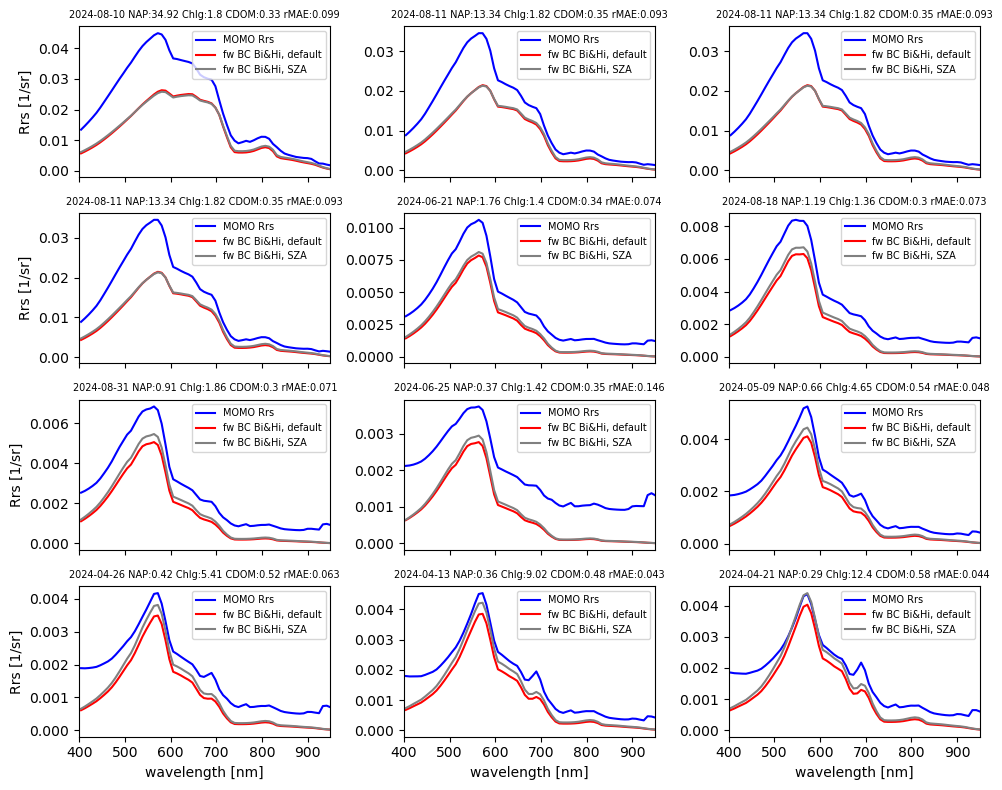

In [36]:
ind = indList
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=False)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl_momo, Rrs_momo.loc[ind[iy*Nx+ix],:].values, 'b-', label='MOMO '+ RrsType)
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO '+ RrsType)
        
        ax[iy, ix].plot(fw_wl, fw_stat.loc[ind[iy*Nx+ix],:].values, 'r-', label='fw BC Bi&Hi, default')
        ax[iy, ix].plot(fw_wl, fw_sza.loc[ind[iy*Nx+ix],:].values, '-', color='grey', label='fw BC Bi&Hi, SZA')
        
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(insitu['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)) +
                            ' Chlg:' + str(np.round(insitu['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 2)) +
                            ' CDOM:' + str(np.round(insitu['ag(440) [1/m]'].loc[ind[iy*Nx+ix]], 2))+
                             ' rMAE:' + str(np.round(spectralError['rMAE'].loc[ind[iy*Nx+ix]], 3)), fontsize=7)
        ax[iy, ix].legend(fontsize=7)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

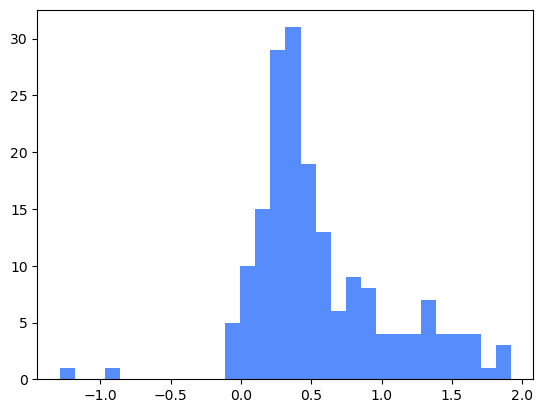

In [21]:
# plt.hist(np.log10(iop_insitu_sel['Chlg [µg/l]'].values), bins=30)
valid = iop_insitu_sel['Chlg [µg/l]'].values > 0.
plt.hist(np.log10(iop_insitu_sel['Chlg [µg/l]'].values[valid]/iop_insitu_sel['NAP [mg/l]'].values[valid]), bins=30)
plt.show()

In [22]:
# Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values)
Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values/iop_insitu_sel['NAP [mg/l]'].values)
valid = iop_insitu_sel['Chlg [µg/l]'].values > 0.
vmin, vmax = (np.min(Y[valid]), np.max(Y[valid]))
print(vmin, vmax)
delta = (vmax-vmin)/(Nx*Ny)
selectCHL_target = np.arange(vmin, vmax, delta*0.999)
indList = []
for logchl in selectCHL_target:
    ID = np.abs(Y - logchl) == np.min(np.abs(Y - logchl))
    if np.sum(ID)>1:
        ID2 = np.where(ID)[0]
        ID3 = np.asarray(ID2)[1:]
        ID[ID3] = False
    
    indList.append(iop_insitu_sel.index[ID])

indList = np.asarray(indList).flatten()
indList

-1.2877567138992292 1.9194396826647246


array(['2024-08-10T00:00:00.000000', '2024-08-11T00:00:00.000000',
       '2024-08-11T00:00:00.000000', '2024-08-11T00:00:00.000000',
       '2024-06-21T00:00:00.000000', '2024-08-18T00:00:00.000000',
       '2024-08-31T00:00:00.000000', '2024-06-25T00:00:00.000000',
       '2024-05-09T00:00:00.000000', '2024-04-26T00:00:00.000000',
       '2024-04-13T00:00:00.000000', '2024-04-21T00:00:00.000000',
       '2024-03-29T00:00:00.000000'], dtype='datetime64[us]')

In [250]:
## select spectra only from the part with systematic errors!
Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values/iop_insitu_sel['NAP [mg/l]'].values)
IDsyst = spectralError['rMAE'].values < poly_fit2(Y)

Y_ = Y[IDsyst]
iop_insitu_sel2 = iop_insitu_sel.loc[IDsyst,:]
             
vmin, vmax = (np.min(Y_), np.max(Y_))
delta = (vmax-vmin)/(Nx*Ny)
selectCHL_target = np.arange(vmin, vmax, delta*0.999)
indList = []
for logchl in selectCHL_target:
    ID = np.abs(Y_ - logchl) == np.min(np.abs(Y_ - logchl))
    if np.sum(ID)>1:
        ID2 = np.where(ID)[0]
        ID3 = np.asarray(ID2)[1:]
        ID[ID3] = False
    
    indList.append(iop_insitu_sel2.index[ID])

indList = np.asarray(indList).flatten()
indList

array(['2022-03-06T00:00:00.000000000', '2022-03-14T00:00:00.000000000',
       '2020-05-28T00:00:00.000000000', '2022-05-30T00:00:00.000000000',
       '2022-04-09T00:00:00.000000000', '2022-05-31T00:00:00.000000000',
       '2018-09-11T00:00:00.000000000', '2018-09-07T00:00:00.000000000',
       '2020-08-22T00:00:00.000000000', '2022-04-13T00:00:00.000000000',
       '2021-07-13T00:00:00.000000000', '2021-07-06T00:00:00.000000000',
       '2021-07-15T00:00:00.000000000'], dtype='datetime64[ns]')

### Characterise the spectral error

In [247]:
def find_systematic_threshold_polynom(regionName, spectralError, Y, x, ax):
    poly_fit2 = None
    if regionName == 'oder-river_frankfurt':
        def f(x):
            return  -0.1*x + 0.125
        ax.plot(x, f(x), 'k-')
        
        ID = spectralError['rMAE'].values < f(Y)
        Y_ = spectralError['rMAE'].values[ID]
        X = Y[ID]
        coefficients = np.polyfit(X,Y_, 5)
        poly_fit = np.poly1d(coefficients)
        ax.plot(x, poly_fit(x), 'b-')
        coeff2 = coefficients.copy()
        coeff2[-1] = 1.2*coeff2[-1]
        poly_fit2 = np.poly1d(coeff2)
        ax.plot(x, poly_fit2(x), 'r-') ## Use these only for a study of the systematic error!
    if regionName == 'oder-river_hohenwutzen':
        ID = spectralError['rMAE'].values < 0.03
        Y_ = spectralError['rMAE'].values[ID]
        X = Y[ID]
        coefficients = np.polyfit(X,Y_, 6)
        poly_fit = np.poly1d(coefficients)
        ax.plot(x, poly_fit(x), 'b-')
        coeff2 = coefficients.copy()
        coeff2[-1] = 1.2*coeff2[-1]
        poly_fit2 = np.poly1d(coeff2)
        ax.plot(x, poly_fit2(x), 'r-') #
    if regionName == 'elbe-river_bunthaus':
        ID = spectralError['rMAE'].values < 0.035
        Y_ = spectralError['rMAE'].values[ID]
        X = Y[ID]
        coefficients = np.polyfit(X,Y_, 6)
        poly_fit = np.poly1d(coefficients)
        ax.plot(x, poly_fit(x), 'b-')
        coeff2 = coefficients.copy()
        coeff2[-1] = 1.4*coeff2[-1]
        poly_fit2 = np.poly1d(coeff2)
        ax.plot(x, poly_fit2(x), 'r-') #
    if regionName == 'mueggelsee':
        # ## from mueggelsee data
        # fit
        coeff3 = [-0.022189, 0.09754511, -0.06850375, -0.07175264, -0.00171725,  0.10119835]
        # fit + offset
        coeff4 = [-0.022189, 0.09754511, -0.06850375, -0.07175264, -0.00171725,  0.12143802]
        poly_fit = np.poly1d(coeff3)
        ax.plot(x, poly_fit(x), 'b-')
        poly_fit2 = np.poly1d(coeff4)
        ax.plot(x, poly_fit2(x), 'r-')
    if regionName == 'dalaro':
        X = Y
        Y = spectralError['rMAE'].values
        coefficients = np.polyfit(X,Y, 4)
        poly_fit = np.poly1d(coefficients)
        ax.plot(x, poly_fit(x), 'b-')
        coeff2 = coefficients.copy()
        coeff2[-1] = 1.1*coeff2[-1]
        poly_fit2 = np.poly1d(coeff2)
        ax.plot(x, poly_fit2(x), 'r-') #
    if regionName == 'pyhajarvi':
        ID = spectralError['rMAE'].values < 0.15
        Y_ = spectralError['rMAE'].values[ID]
        X = Y[ID]
        coefficients = np.polyfit(X,Y_, 5)
        poly_fit = np.poly1d(coefficients)
        ax.plot(x, poly_fit(x), 'b-')
        coeff2 = coefficients.copy()
        coeff2[-1] = 1.05*np.abs(coeff2[-1])
        poly_fit2 = np.poly1d(coeff2)
        ax.plot(x, poly_fit2(x), 'r-') #
    if regionName == 'uto':
        def poly_fit2(x): 
            return np.zeros(len(x)) + 0.15
        ax.plot(x, poly_fit2(x), 'r-') #
    return poly_fit2

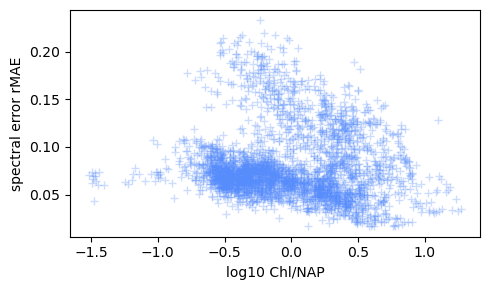

In [52]:
## characterise systematic error ##
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(Y, spectralError['rMAE'].values, '+', alpha=0.3)
x = np.arange(vmin, vmax, (vmax-vmin) /100.)

## fit systematic error part: select rMAE < f(x)
# poly_fit2 = find_systematic_threshold_polynom(regionName, spectralError, Y, x, ax)

ax.set_ylabel('spectral error rMAE')
ax.set_xlabel('log10 Chl/NAP')

if regionName == 'oder-river_hohenwutzen':
    ax.set_xlim((-2, 1.2))
    ax.set_ylim((0.01, 0.1))
elif regionName == 'elbe-river_seemannshöft':
    ax.set_xlim((-2, 0.2))
    ax.set_ylim((0.0, 0.5))
elif regionName == 'elbe-river_bunthaus':
    ax.set_xlim((-1.5, 1))
    ax.set_ylim((0.0, 0.15))
if regionName == 'dalaro':
    ax.set_xlim((-0.3, 2))
    ax.set_ylim((0.0, 0.2))
    
fig.tight_layout()
plt.show()

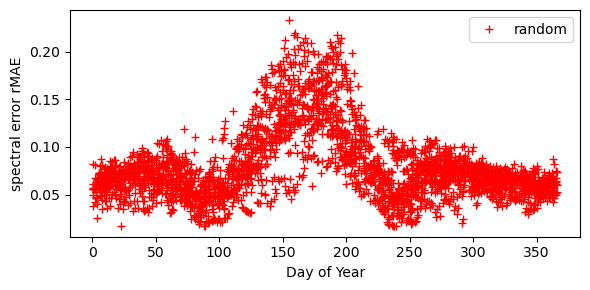

In [51]:
## plot timeseries: all errors and systematic ones
fig, ax = plt.subplots(figsize=(6,3))
doy = np.asarray([a.day_of_year for a in spectralError.index])
ax.plot(doy, spectralError['rMAE'], 'r+', label='random')
# if not regionName == 'elbe-river_seemannshöft' and not regionName == 'malaren':
#     IDsyst = spectralError['rMAE'].values < poly_fit2(Y)
#     ax.plot(doy[IDsyst], spectralError['rMAE'].loc[IDsyst], 'b+', label='systematic')
ax.legend()
# perc = np.nanpercentile(spectralError['rMAE'].values, 99)
# ax.set_ylim((0, perc))
ax.set_ylabel('spectral error rMAE')
ax.set_xlabel('Day of Year')
fig.tight_layout()
plt.show()

# Check Inversion
- How well can we reproduce the input concentrations within our own framework?
- How well works the retrieval on MOMO spectra?

Example: Dalarö: two components -> diatoms and cyanobacteria

## Run Inversion on the CHIME band simulations
- run inversion on MOMO v0.4 (with and without glint)
- run inversion on Bi-forward simulations

### Read Inversion bio-optics

In [38]:
## SZA dependent
spath = "Z:\projects\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward_withSZA\\"
fnames = os.listdir(spath)
fnames = [fn for fn in fnames if regionName in fn]
# fnames = [fn for fn in fnames if 'CHIMEbands' in fn]

fnames
# fw_sza = pd.read_csv(spath + fnames[0], header=0, sep='\t')
# fw_sza = fw_sza.set_index(insitu.index)
# fw_sza

['SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0.1c_AngleDepSZA_CHIMEbands.txt',
 'SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0.1_AngleDepSZA.txt']

In [ ]:
algList = ['Ckie [µg/l]', 'Cbl [µg/l]']
colorList = ['brown', 'blue']
algInvList = ['C_0', 'C_3']
colorInvList = ['goldenrod', 'aqua']

plotsemilog = False

fig, ax=plt.subplots(nrows=2, figsize=(10,6))
for i in range(len(algList)):
    ID = insitu[algList[i]] > 0.1
    if plotsemilog:
        ax[0].semilogy(insitu[algList[i]].loc[ID], '+', color=colorList[i], label=algList[i])
    else:
        ax[0].plot(insitu[algList[i]].loc[ID], '+', color=colorList[i], label=algList[i])

    ID = inv[algInvList[i]] > 0.11
    if plotsemilog:
        ax[0].semilogy(inv[algInvList[i]].loc[ID], 'x', color=colorInvList[i], label=algInvList[i])
    else:
        ax[0].plot(inv[algInvList[i]].loc[ID], 'x', color=colorInvList[i], label=algInvList[i])

    # ax[1].plot(spectralErrorDF['absErr'], '+')

if plotsemilog:
    ax[0].set_ylim((0.1, 60))
else:
    ax[0].set_ylim((-5,60))

ax[0].legend()
fig.tight_layout()
plt.show()